# Analiza Miar Ryzyka — XTB S.A.
## Zarządzanie Ryzykiem w Przedsiębiorstwie — Projekt 3

**Zmienne ryzyka:**
- **EUR/PLN** — kurs euro do złotego
- **USD/PLN** — kurs dolara do złotego  
- **GBP/PLN** — kurs funta do złotego
- **XTB.WA** — cena akcji XTB na GPW

XTB S.A. jest brokerem forex/CFD notowanym na GPW. Przychody spółki zależą silnie od kursów walut (prowizje od transakcji klientów) oraz od wyceny giełdowej. Około 50% przychodów generowanych jest w EUR, 30% w USD, 20% w GBP — te wagi wykorzystamy do budowy portfela walutowego.

**Podejście:** parametryczne (dopasowanie rozkładu normalnego i t-Studenta) + nieparametryczne (empiryczne miary) — porównanie obu.

**Dane:** dzienne kursy zamknięcia z ostatnich 3 lat (via `yfinance`). Jako zmienną ryzyka wykorzystujemy **logarytmiczne stopy zwrotu** (log-returns), co eliminuje niestacjonarność i autokorelację poziomów cen.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import norm, t as t_dist, genextreme, genpareto
from scipy.stats import kstest, anderson
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# ---------- Pobieranie danych ----------
tickers = {
    'EURPLN=X': 'EUR/PLN',
    'USDPLN=X': 'USD/PLN',
    'GBPPLN=X': 'GBP/PLN',
    'XTB.WA':   'XTB.WA'
}

data = yf.download(list(tickers.keys()), start='2018-01-01', end='2025-12-31')['Close']
data.columns = [tickers.get(c, c) for c in data.columns]
data = data.dropna()

# Logarytmiczne stopy zwrotu
log_returns = np.log(data / data.shift(1)).dropna()

print(f"Okres: {data.index[0].date()} — {data.index[-1].date()}")
print(f"Liczba obserwacji (ceny): {len(data)}")
print(f"Liczba obserwacji (log-returns): {len(log_returns)}")
print(f"\nStatystyki opisowe log-returns (dzienne):")
log_returns.describe().T

[*********************100%***********************]  4 of 4 completed

Okres: 2018-01-01 — 2025-12-30
Liczba obserwacji (ceny): 2030
Liczba obserwacji (log-returns): 2029

Statystyki opisowe log-returns (dzienne):


,count,mean,std,min,25%,50%,75%,max
EUR/PLN,2029.0,0.000005,0.003675,-0.021017,-0.001985,-0.000097,0.001768,0.024335
GBP/PLN,2029.0,0.000017,0.005349,-0.031250,-0.002937,-0.000030,0.003046,0.032354
USD/PLN,2029.0,0.000015,0.006633,-0.038123,-0.003861,-0.000166,0.003641,0.042147
XTB.WA,2029.0,0.001661,0.029527,-0.375975,-0.011437,0.000000,0.013254,0.305886


TEST STACJONARNOŚCI — ADF & KPSS

──────────────────────────────────────────────────────────────────────
  Kursy zamknięcia
──────────────────────────────────────────────────────────────────────
         ADF stat  ADF p-value  ADF lags  KPSS stat  KPSS p-value Stacjonarny?
Zmienna                                                                       
EUR/PLN   -2.0612       0.2604        11     1.5335          0.01          NIE
GBP/PLN   -2.8152       0.0561         0     2.1091          0.01          NIE
USD/PLN   -2.2692       0.1821         1     1.7007          0.01          NIE
XTB.WA     0.4884       0.9845        14     6.0216          0.01          NIE

──────────────────────────────────────────────────────────────────────
  Log-zwroty
──────────────────────────────────────────────────────────────────────
         ADF stat  ADF p-value  ADF lags  KPSS stat  KPSS p-value Stacjonarny?
Zmienna                                                                       
EUR/PLN  -14.9504

/var/folders/f5/4k5qrc256832lvh3kr6862w00000gn/T/ipykernel_6031/4106027363.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(s, regression='c', nlags='auto')
/var/folders/f5/4k5qrc256832lvh3kr6862w00000gn/T/ipykernel_6031/4106027363.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(s, regression='c', nlags='auto')
/var/folders/f5/4k5qrc256832lvh3kr6862w00000gn/T/ipykernel_6031/4106027363.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(s, regression='c', nlags='auto')
/var/fo

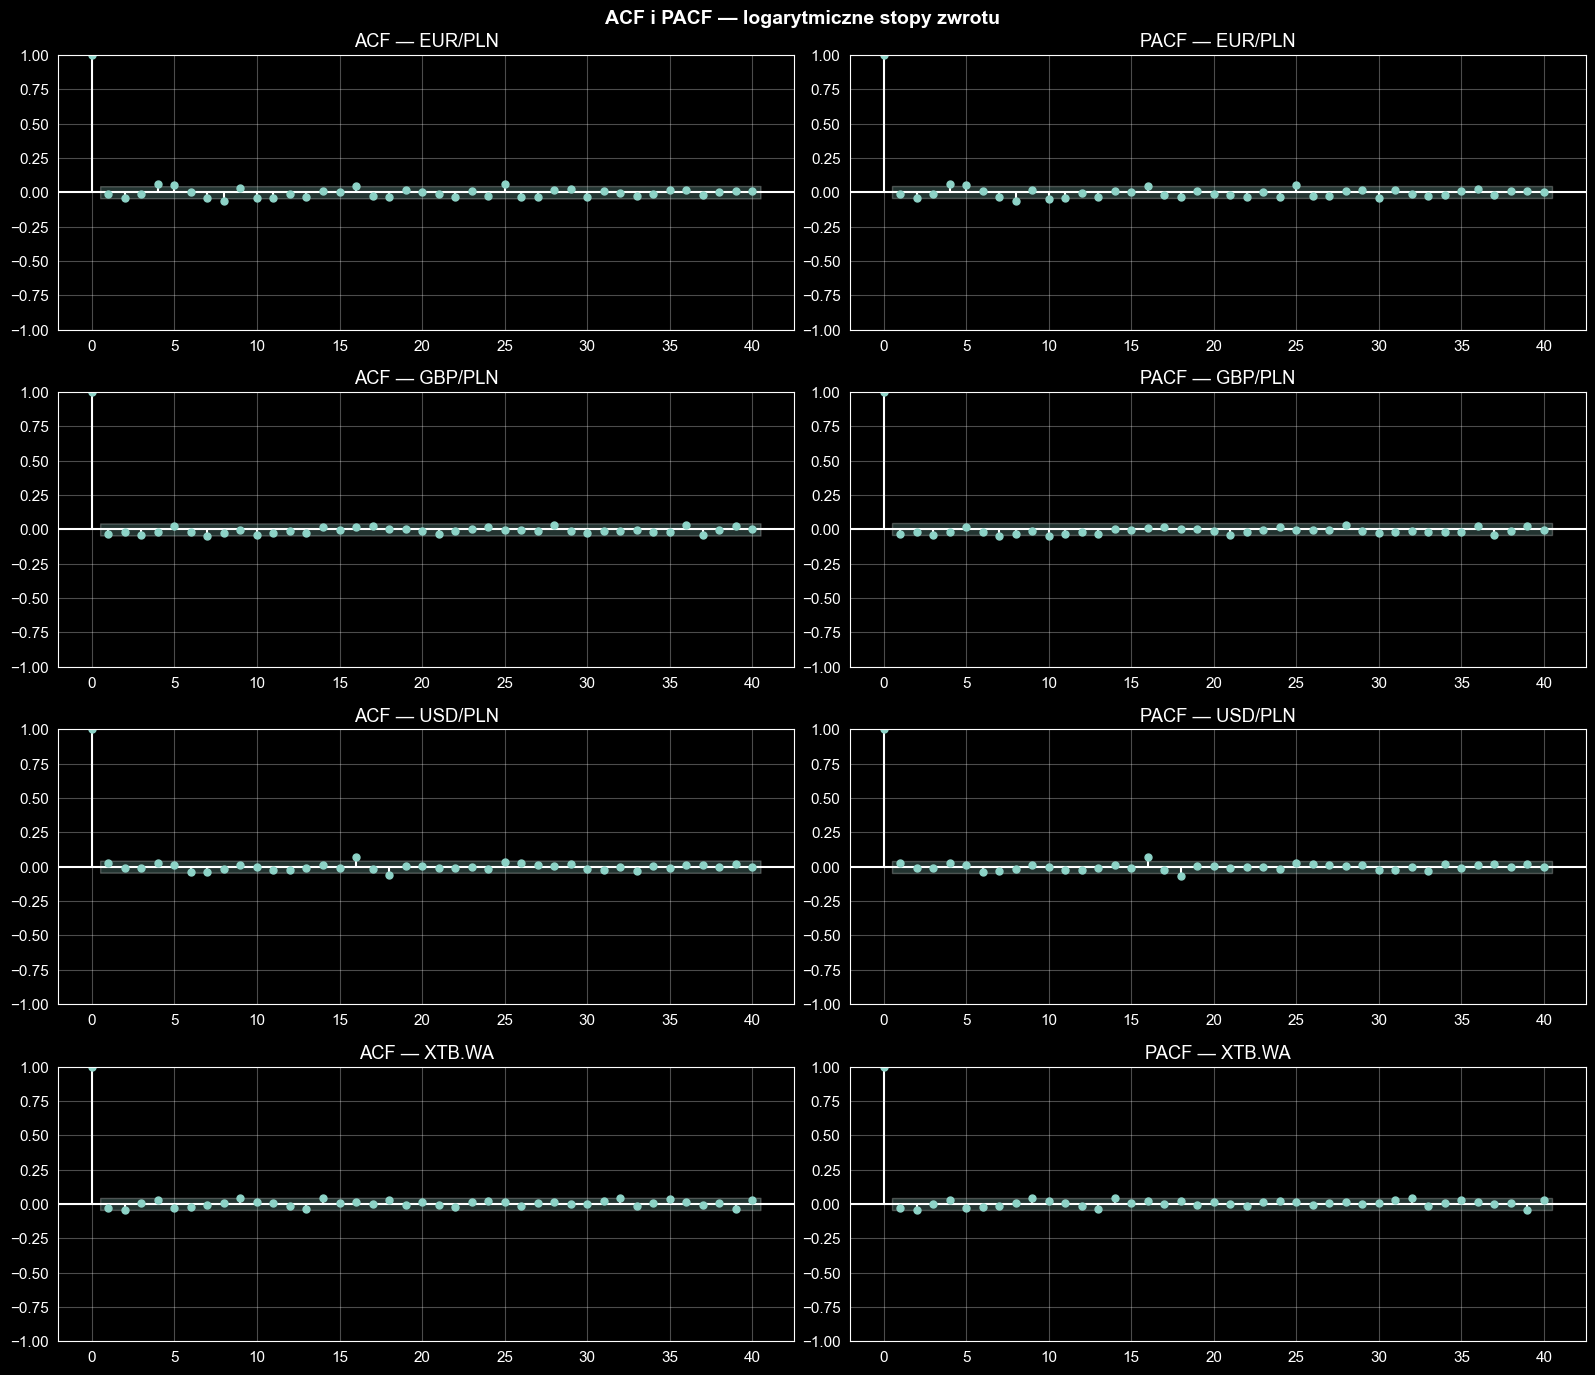

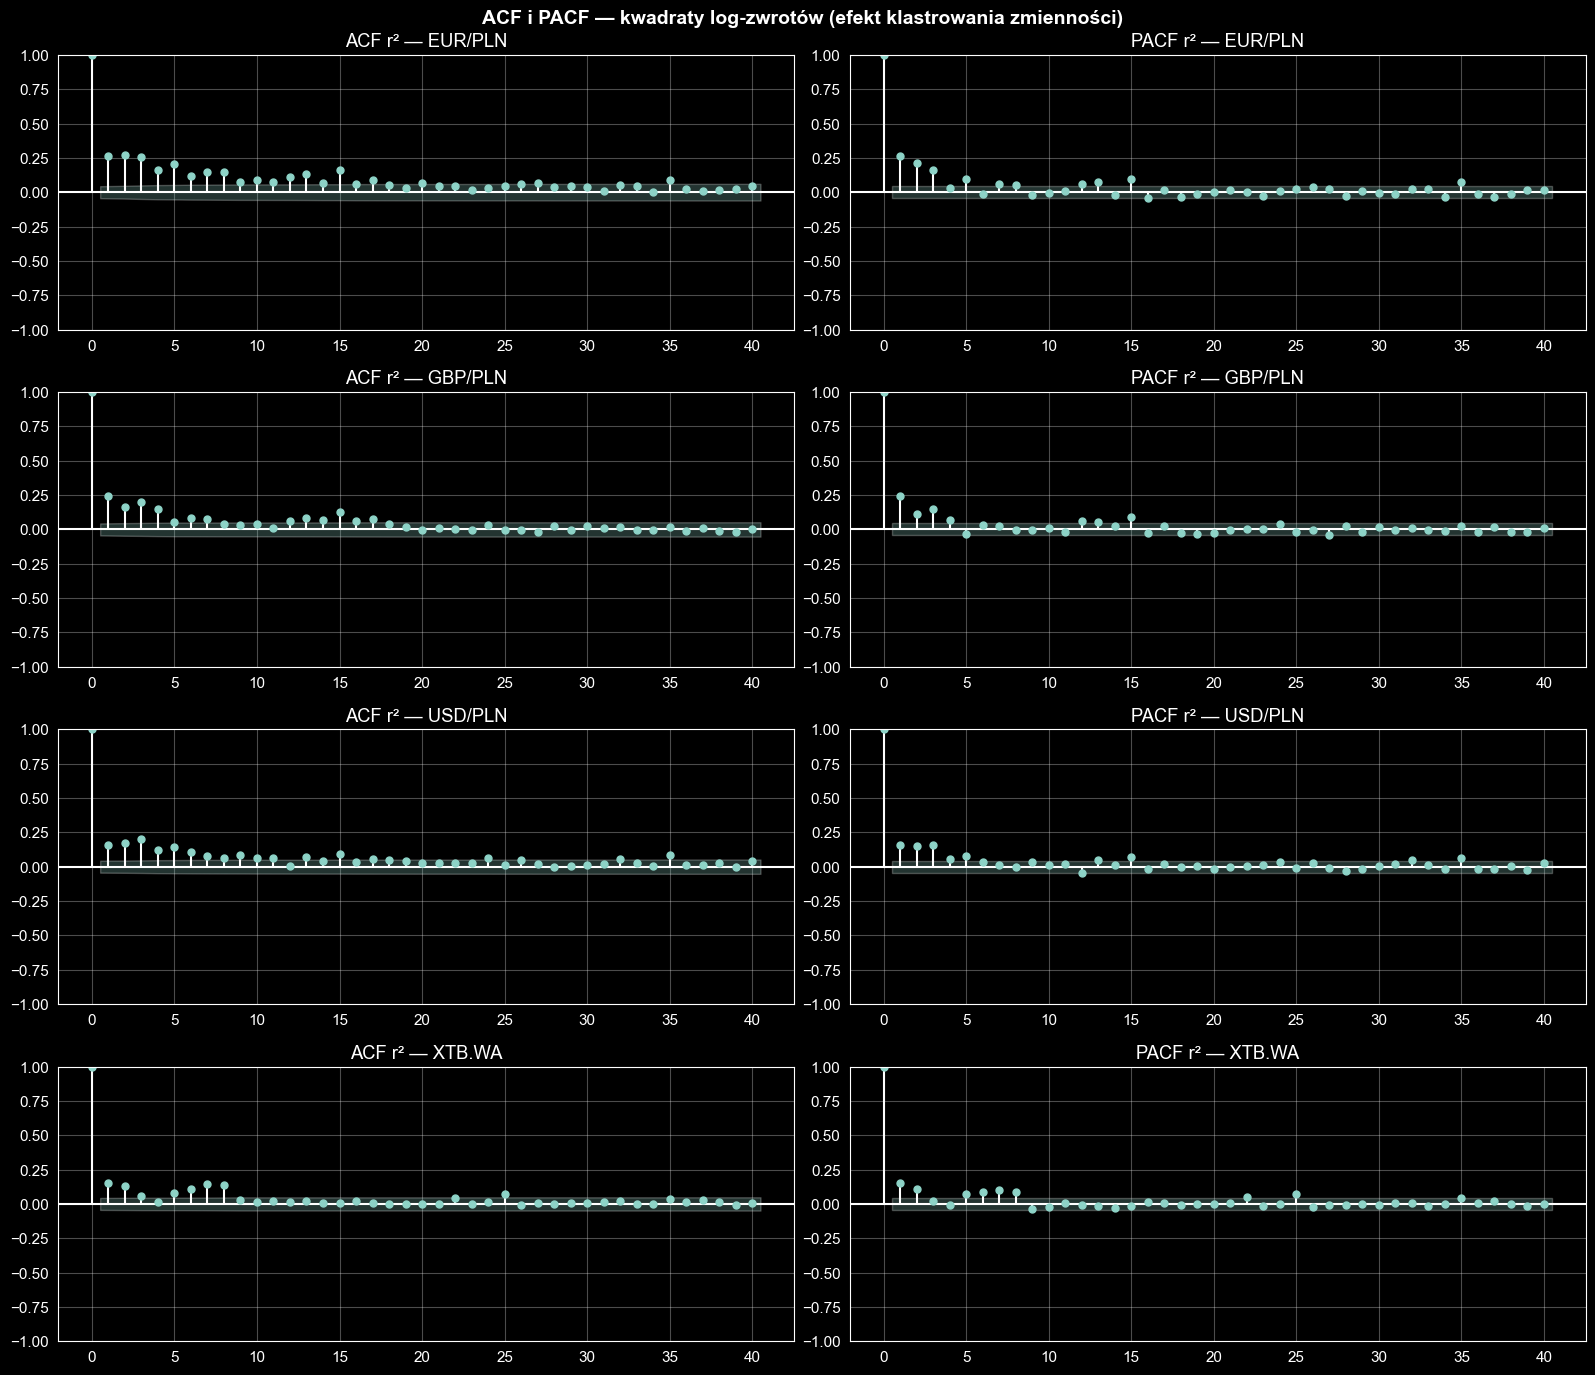

In [2]:
# ---------- Test stacjonarności + ACF / PACF ----------
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# === Test ADF i KPSS dla kursów zamknięcia i log-zwrotów ===
print("=" * 70)
print("TEST STACJONARNOŚCI — ADF & KPSS")
print("=" * 70)

for label, series_dict in [("Kursy zamknięcia", data), ("Log-zwroty", log_returns)]:
    print(f"\n{'─'*70}")
    print(f"  {label}")
    print(f"{'─'*70}")
    rows = []
    for col in log_returns.columns:
        s = series_dict[col].dropna()
        # ADF (H0: jest pierwiastek jednostkowy → niestacjonarny)
        adf_stat, adf_p, adf_lags, *_ = adfuller(s, autolag='AIC')
        # KPSS (H0: szereg jest stacjonarny)
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(s, regression='c', nlags='auto')
        rows.append({
            'Zmienna': col,
            'ADF stat': round(adf_stat, 4),
            'ADF p-value': round(adf_p, 4),
            'ADF lags': adf_lags,
            'KPSS stat': round(kpss_stat, 4),
            'KPSS p-value': round(kpss_p, 4),
            'Stacjonarny?': 'TAK' if adf_p < 0.05 and kpss_p > 0.05 else 'NIE'
        })
    df_tests = pd.DataFrame(rows).set_index('Zmienna')
    print(df_tests.to_string())

# === ACF i PACF dla log-zwrotów ===
fig, axes = plt.subplots(len(log_returns.columns), 2, figsize=(16, 3.5 * len(log_returns.columns)))
fig.suptitle('ACF i PACF — logarytmiczne stopy zwrotu', fontsize=14, fontweight='bold')

for i, col in enumerate(log_returns.columns):
    plot_acf(log_returns[col].dropna(), ax=axes[i, 0], lags=40, title=f'ACF — {col}', alpha=0.05)
    plot_pacf(log_returns[col].dropna(), ax=axes[i, 1], lags=40, title=f'PACF — {col}', alpha=0.05, method='ywm')
    axes[i, 0].grid(alpha=0.3)
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# === ACF i PACF dla kwadratów log-zwrotów (efekt ARCH) ===
fig, axes = plt.subplots(len(log_returns.columns), 2, figsize=(16, 3.5 * len(log_returns.columns)))
fig.suptitle('ACF i PACF — kwadraty log-zwrotów (efekt klastrowania zmienności)', fontsize=14, fontweight='bold')

for i, col in enumerate(log_returns.columns):
    sq = log_returns[col].dropna() ** 2
    plot_acf(sq, ax=axes[i, 0], lags=40, title=f'ACF r² — {col}', alpha=0.05)
    plot_pacf(sq, ax=axes[i, 1], lags=40, title=f'PACF r² — {col}', alpha=0.05, method='ywm')
    axes[i, 0].grid(alpha=0.3)
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

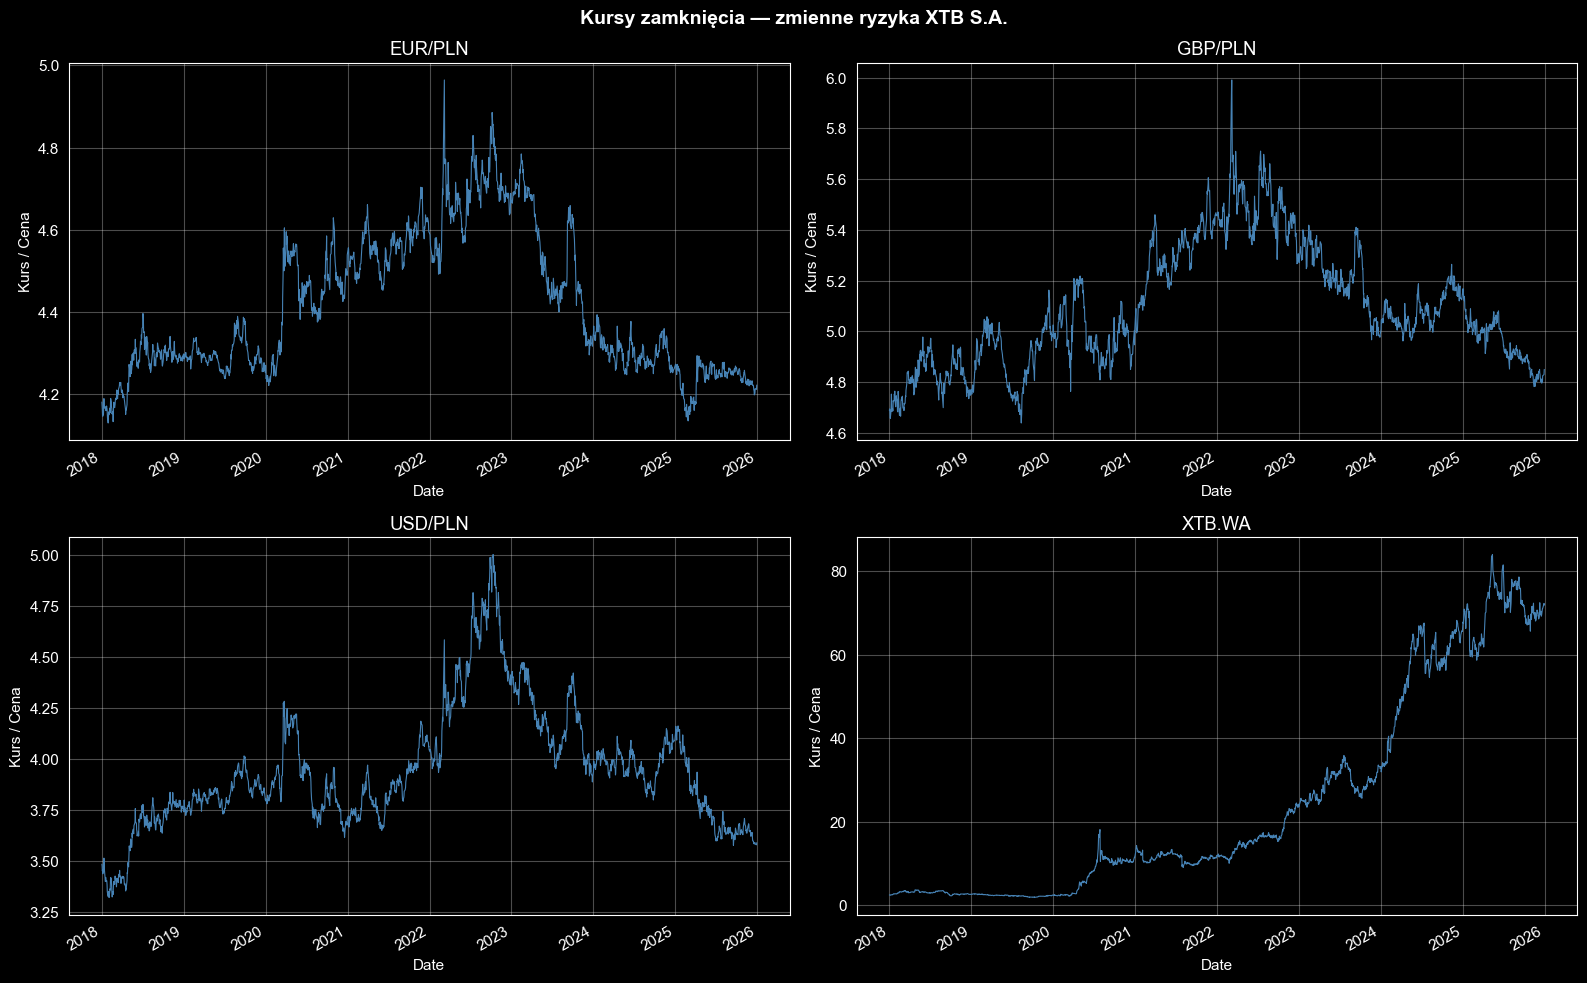

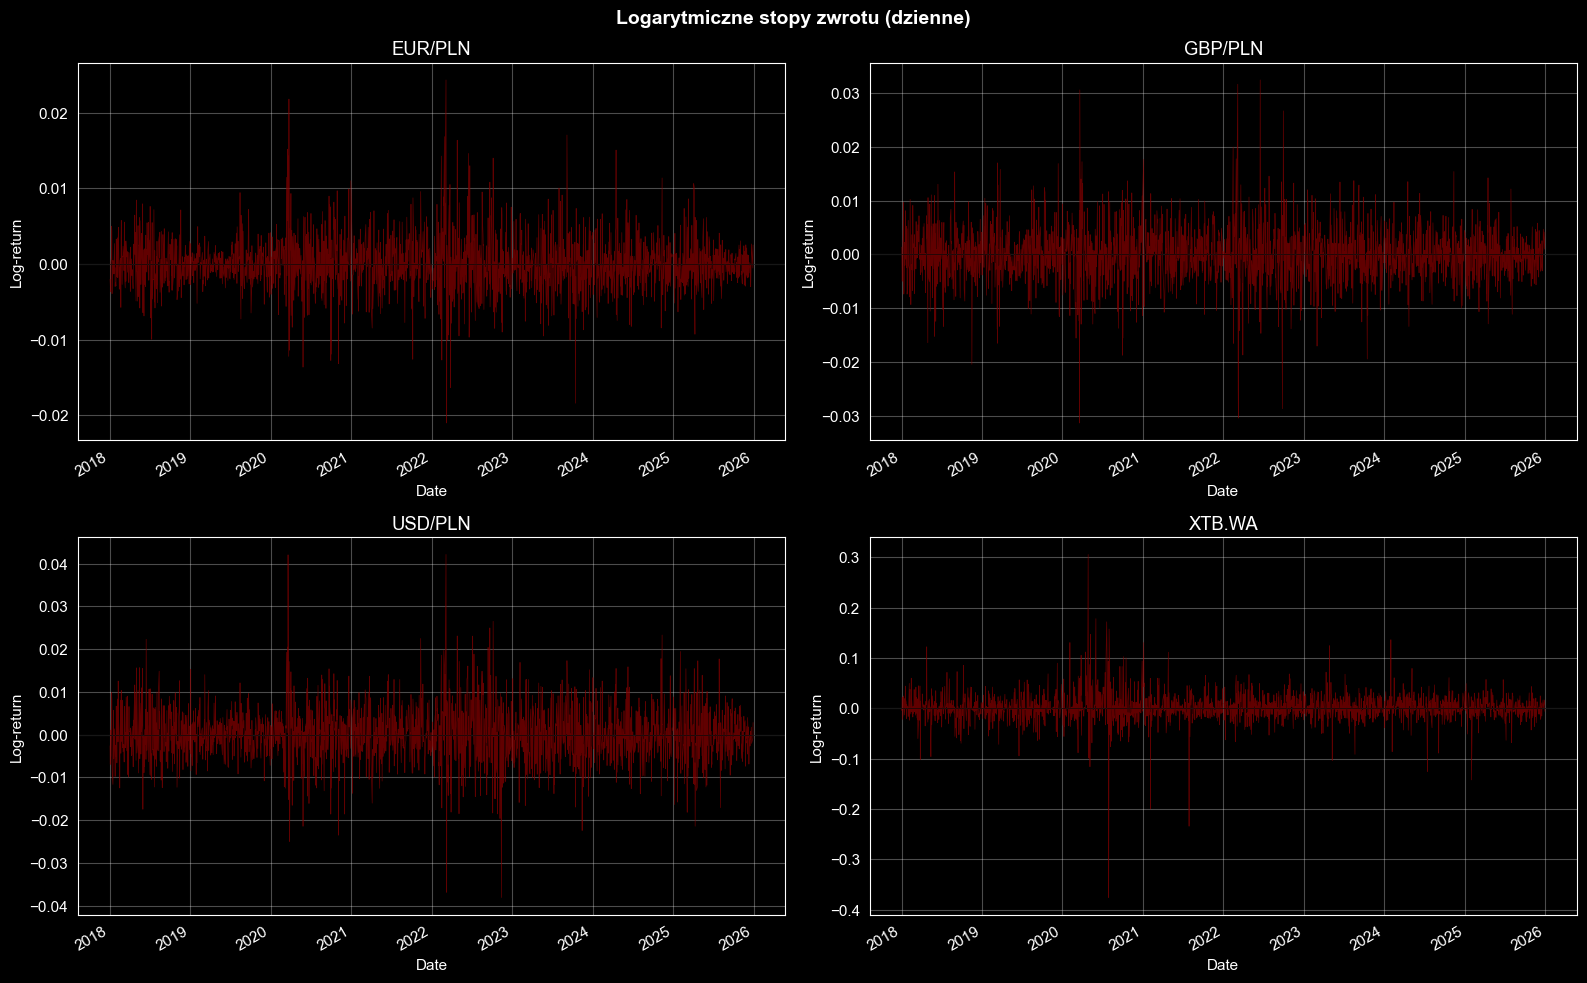

In [3]:
# ---------- Wizualizacja danych ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Kursy zamknięcia — zmienne ryzyka XTB S.A.', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, log_returns.columns):
    data[col].plot(ax=ax, color='steelblue', linewidth=0.8)
    ax.set_title(col)
    ax.set_ylabel('Kurs / Cena')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Logarytmiczne stopy zwrotu (dzienne)', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, log_returns.columns):
    log_returns[col].plot(ax=ax, color='darkred', linewidth=0.5, alpha=0.7)
    ax.set_title(col)
    ax.set_ylabel('Log-return')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# 1. Przypadek jednowymiarowy

Dla każdej zmiennej ryzyka osobno wyznaczamy:
- **a) Miary zmienności:** odchylenie standardowe, wariancja, rozstęp międzykwartylowy (IQR), MAD
- **b) Kwantyle:** VaR na poziomach 95%, 99% (empiryczny i parametryczny)
- **c) Wartości dystrybuanty:** F(0), F(μ±σ), F(μ±2σ) + porównanie graficzne CDF empirycznej z teoretyczną

In [4]:
# ============================================================
# 1a. Miary zmienności — przypadek jednowymiarowy
# ============================================================

def compute_volatility_measures(returns_series):
    """Oblicza miary zmienności dla pojedynczej zmiennej."""
    return {
        'Średnia (μ)': returns_series.mean(),
        'Odch. std. (σ)': returns_series.std(),
        'Wariancja (σ²)': returns_series.var(),
        'σ annualizowane': returns_series.std() * np.sqrt(252),
        'IQR': returns_series.quantile(0.75) - returns_series.quantile(0.25),
        'MAD': np.median(np.abs(returns_series - returns_series.median())),
        'Skośność': returns_series.skew(),
        'Kurtoza (exc.)': returns_series.kurtosis(),
    }

vol_table = pd.DataFrame({col: compute_volatility_measures(log_returns[col]) 
                           for col in log_returns.columns})

print("=" * 70)
print("1a. MIARY ZMIENNOŚCI — przypadek jednowymiarowy")
print("=" * 70)
vol_table.round(6)

1a. MIARY ZMIENNOŚCI — przypadek jednowymiarowy


,EUR/PLN,GBP/PLN,USD/PLN,XTB.WA
Średnia (μ),0.000005,0.000017,0.000015,0.001661
Odch. std. (σ),0.003675,0.005349,0.006633,0.029527
Wariancja (σ²),0.000014,0.000029,0.000044,0.000872
σ annualizowane,0.058347,0.084920,0.105296,0.468727
IQR,0.003753,0.005983,0.007503,0.024690
MAD,0.001872,0.002963,0.003769,0.012397
Skośność,0.336929,0.038931,0.189628,-0.442616
Kurtoza (exc.),4.477672,3.993207,3.228982,25.419645


In [5]:
# ============================================================
# 1b. Kwantyle — VaR (Value at Risk) empiryczny i parametryczny
# ============================================================

alpha_levels = [0.01, 0.05, 0.10]

print("=" * 70)
print("1b. KWANTYLE / VaR — przypadek jednowymiarowy")
print("=" * 70)

# Dopasowanie rozkładów: Normal i t-Studenta
fitted_params = {}

for col in log_returns.columns:
    r = log_returns[col].values
    mu, sigma = r.mean(), r.std()
    # t-Studenta: MLE
    df_t, loc_t, scale_t = t_dist.fit(r)
    fitted_params[col] = {
        'norm': (mu, sigma),
        't': (df_t, loc_t, scale_t)
    }

# Tabela VaR
var_results = []
for col in log_returns.columns:
    r = log_returns[col].values
    mu_n, sig_n = fitted_params[col]['norm']
    df_t, loc_t, scale_t = fitted_params[col]['t']
    
    for alpha in alpha_levels:
        var_emp = np.percentile(r, alpha * 100)
        var_norm = norm.ppf(alpha, loc=mu_n, scale=sig_n)
        var_t = t_dist.ppf(alpha, df_t, loc=loc_t, scale=scale_t)
        
        # ES (Expected Shortfall / CVaR) — średnia strat poniżej VaR
        es_emp = r[r <= var_emp].mean()
        
        var_results.append({
            'Zmienna': col,
            'α': f'{alpha:.0%}',
            'VaR emp.': f'{var_emp:.5f}',
            'VaR Normal': f'{var_norm:.5f}',
            'VaR t-Student': f'{var_t:.5f}',
            'ES emp.': f'{es_emp:.5f}',
        })

var_df = pd.DataFrame(var_results)
print("\nVaR = kwantyl α (interpretacja: z prawdopodobieństwem α strata przekroczy |VaR|)")
print("ES = Expected Shortfall (średnia strat w ogonie poniżej VaR)\n")
var_df

1b. KWANTYLE / VaR — przypadek jednowymiarowy

VaR = kwantyl α (interpretacja: z prawdopodobieństwem α strata przekroczy |VaR|)
ES = Expected Shortfall (średnia strat w ogonie poniżej VaR)



,Zmienna,α,VaR emp.,VaR Normal,VaR t-Student,ES emp.
0,EUR/PLN,1%,-0.00913,-0.00854,-0.01010,-0.01255
1,EUR/PLN,5%,-0.00540,-0.00604,-0.00574,-0.00786
2,EUR/PLN,10%,-0.00391,-0.00470,-0.00415,-0.00626
3,GBP/PLN,1%,-0.01360,-0.01242,-0.01403,-0.01859
4,GBP/PLN,5%,-0.00840,-0.00878,-0.00831,-0.01199
5,GBP/PLN,10%,-0.00589,-0.00684,-0.00606,-0.00949
6,USD/PLN,1%,-0.01686,-0.01541,-0.02795,-0.02147
7,USD/PLN,5%,-0.00989,-0.01089,-0.01266,-0.01427
8,USD/PLN,10%,-0.00745,-0.00848,-0.00852,-0.01147
9,XTB.WA,1%,-0.06772,-0.06701,-0.08105,-0.12234


In [6]:
# ============================================================
# 1c. Dystrybuanty — porównanie empirycznej z teoretyczną
# ============================================================

print("=" * 70)
print("1c. DYSTRYBUANTY — przypadek jednowymiarowy")
print("=" * 70)

# Wartości dystrybuanty w wybranych punktach
print("\nWartości dystrybuanty empirycznej i teoretycznej w wybranych punktach:")
print("(F(0) = P(R ≤ 0), czyli prawdopodobieństwo straty)\n")

cdf_results = []
for col in log_returns.columns:
    r = log_returns[col].values
    mu_n, sig_n = fitted_params[col]['norm']
    df_t, loc_t, scale_t = fitted_params[col]['t']
    
    points = {
        'F(0)': 0,
        'F(μ-2σ)': mu_n - 2*sig_n,
        'F(μ-σ)': mu_n - sig_n,
        'F(μ)': mu_n,
        'F(μ+σ)': mu_n + sig_n,
        'F(μ+2σ)': mu_n + 2*sig_n,
    }
    
    for label, x in points.items():
        f_emp = np.mean(r <= x)
        f_norm = norm.cdf(x, loc=mu_n, scale=sig_n)
        f_t = t_dist.cdf(x, df_t, loc=loc_t, scale=scale_t)
        cdf_results.append({
            'Zmienna': col, 'Punkt': label, 'x': f'{x:.6f}',
            'F_emp': f'{f_emp:.4f}', 'F_norm': f'{f_norm:.4f}', 'F_t': f'{f_t:.4f}'
        })

cdf_df = pd.DataFrame(cdf_results)
cdf_df

1c. DYSTRYBUANTY — przypadek jednowymiarowy

Wartości dystrybuanty empirycznej i teoretycznej w wybranych punktach:
(F(0) = P(R ≤ 0), czyli prawdopodobieństwo straty)



,Zmienna,Punkt,x,F_emp,F_norm,F_t
0,EUR/PLN,F(0),0.000000,0.5150,0.4995,0.5175
1,EUR/PLN,F(μ-2σ),-0.007344,0.0192,0.0228,0.0262
2,EUR/PLN,F(μ-σ),-0.003670,0.1138,0.1587,0.1240
3,EUR/PLN,F(μ),0.000005,0.5160,0.5000,0.5182
4,EUR/PLN,F(μ+σ),0.003679,0.8753,0.8413,0.8893
5,EUR/PLN,F(μ+2σ),0.007354,0.9724,0.9772,0.9762
6,GBP/PLN,F(0),0.000000,0.5052,0.4988,0.5003
7,GBP/PLN,F(μ-2σ),-0.010679,0.0232,0.0228,0.0248
8,GBP/PLN,F(μ-σ),-0.005331,0.1242,0.1587,0.1252
9,GBP/PLN,F(μ),0.000017,0.5062,0.5000,0.5018


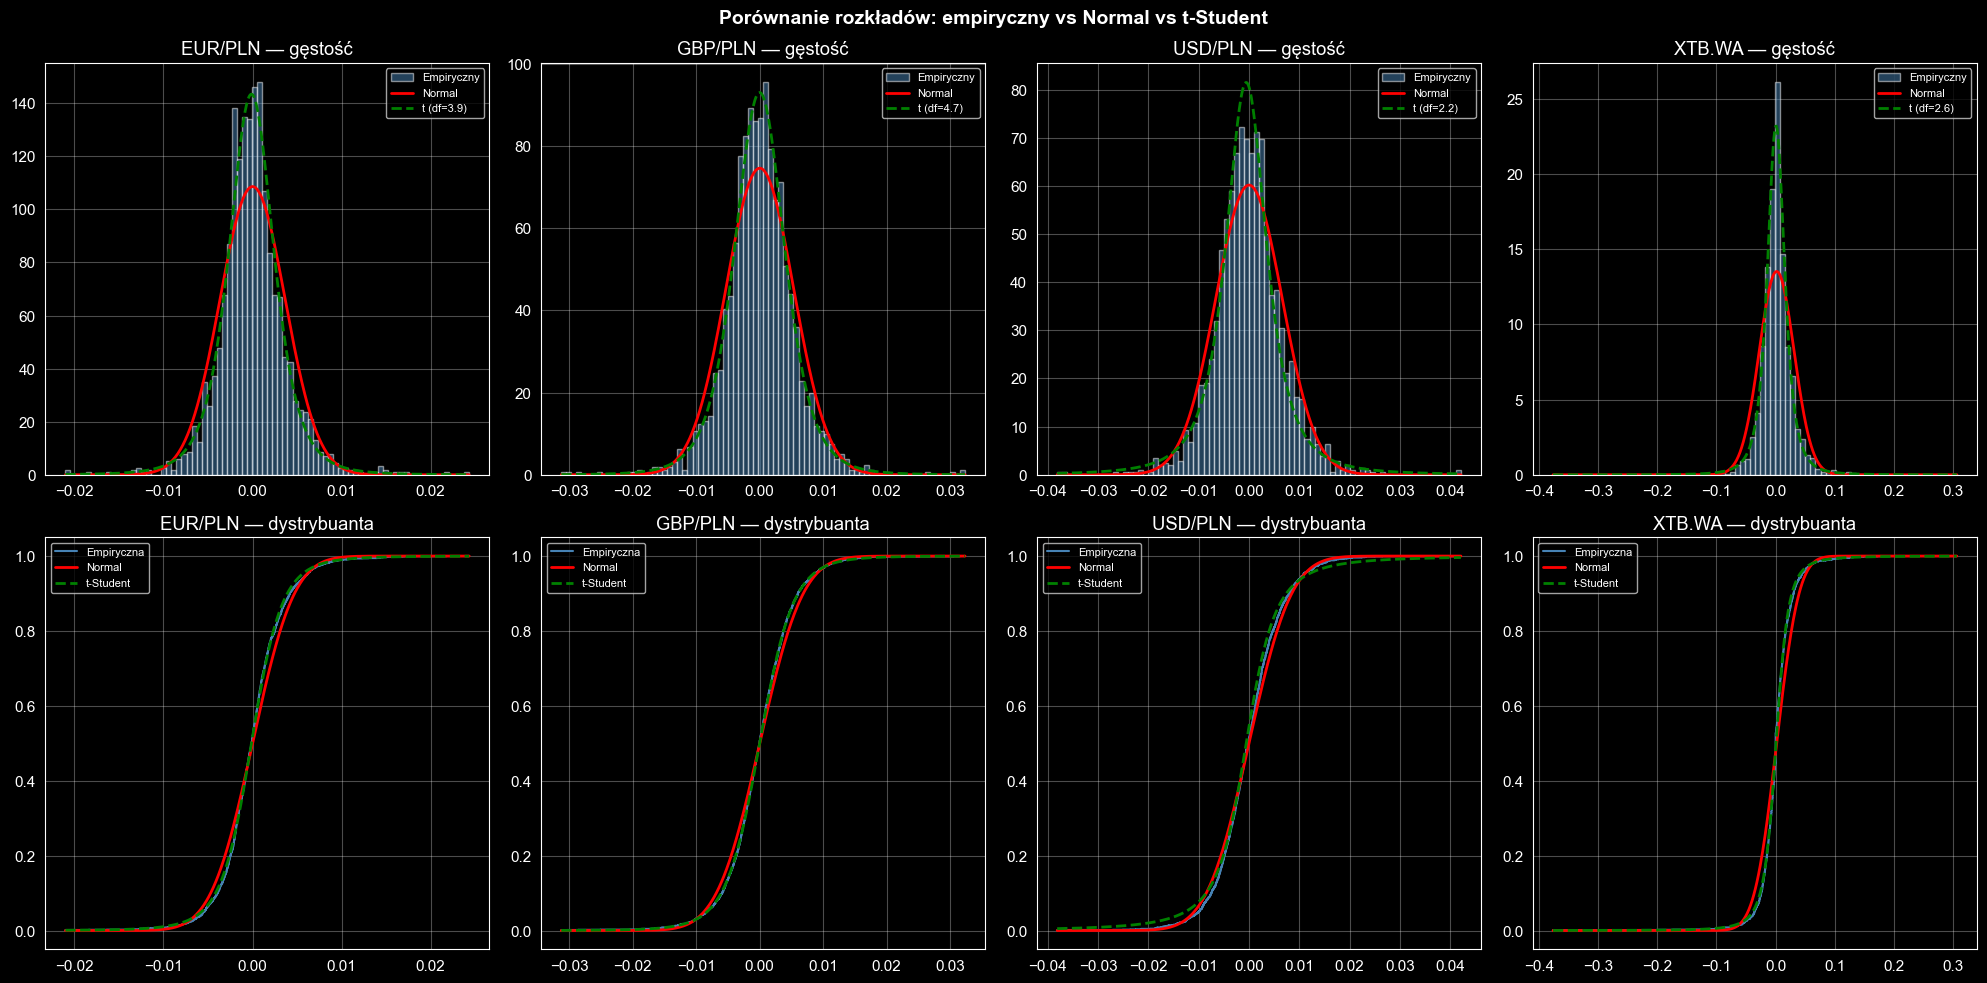

In [7]:
# Graficzne porównanie CDF + histogramy z dopasowanymi gęstościami
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Porównanie rozkładów: empiryczny vs Normal vs t-Student', fontsize=14, fontweight='bold')

for i, col in enumerate(log_returns.columns):
    r = log_returns[col].values
    mu_n, sig_n = fitted_params[col]['norm']
    df_t, loc_t, scale_t = fitted_params[col]['t']
    x_grid = np.linspace(r.min(), r.max(), 500)
    
    # Histogram + gęstości
    ax = axes[0, i]
    ax.hist(r, bins=80, density=True, alpha=0.5, color='steelblue', label='Empiryczny')
    ax.plot(x_grid, norm.pdf(x_grid, mu_n, sig_n), 'r-', lw=2, label='Normal')
    ax.plot(x_grid, t_dist.pdf(x_grid, df_t, loc_t, scale_t), 'g--', lw=2, label=f't (df={df_t:.1f})')
    ax.set_title(f'{col} — gęstość')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    # CDF
    ax2 = axes[1, i]
    sorted_r = np.sort(r)
    ecdf = np.arange(1, len(sorted_r)+1) / len(sorted_r)
    ax2.step(sorted_r, ecdf, color='steelblue', lw=1.5, label='Empiryczna')
    ax2.plot(x_grid, norm.cdf(x_grid, mu_n, sig_n), 'r-', lw=2, label='Normal')
    ax2.plot(x_grid, t_dist.cdf(x_grid, df_t, loc_t, scale_t), 'g--', lw=2, label='t-Student')
    ax2.set_title(f'{col} — dystrybuanta')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Test zgodności z rozkładem — Kolmogorov-Smirnov
print("Test Kołmogorowa-Smirnowa (H0: dane pochodzą z danego rozkładu):\n")

ks_results = []
for col in log_returns.columns:
    r = log_returns[col].values
    mu_n, sig_n = fitted_params[col]['norm']
    df_t, loc_t, scale_t = fitted_params[col]['t']
    
    ks_norm = kstest(r, 'norm', args=(mu_n, sig_n))
    ks_t = kstest(r, 't', args=(df_t, loc_t, scale_t))
    
    ks_results.append({
        'Zmienna': col,
        'KS stat (Normal)': f'{ks_norm.statistic:.4f}',
        'p-value (Normal)': f'{ks_norm.pvalue:.4f}',
        'KS stat (t-Stud.)': f'{ks_t.statistic:.4f}',
        'p-value (t-Stud.)': f'{ks_t.pvalue:.4f}',
    })

ks_df = pd.DataFrame(ks_results)
print("p-value < 0.05 → odrzucamy H0 (rozkład nie pasuje)")
print("p-value ≥ 0.05 → brak podstaw do odrzucenia H0\n")
ks_df

Test Kołmogorowa-Smirnowa (H0: dane pochodzą z danego rozkładu):

p-value < 0.05 → odrzucamy H0 (rozkład nie pasuje)
p-value ≥ 0.05 → brak podstaw do odrzucenia H0



,Zmienna,KS stat (Normal),p-value (Normal),KS stat (t-Stud.),p-value (t-Stud.)
0,EUR/PLN,0.0671,0.0000,0.0162,0.6572
1,GBP/PLN,0.0484,0.0001,0.0107,0.9714
2,USD/PLN,0.0481,0.0002,0.0459,0.0004
3,XTB.WA,0.1041,0.0000,0.0398,0.0032


---
# 2. Przypadek wielowymiarowy — portfel walutowy XTB

Budujemy portfel z 3 kursów walutowych (EUR/PLN, USD/PLN, GBP/PLN) z wagami odpowiadającymi przybliżonej strukturze przychodów XTB S.A.:
- **EUR/PLN: 50%** (główny rynek — Europa)
- **USD/PLN: 30%** (rynki dolarowe)
- **GBP/PLN: 20%** (rynek brytyjski)

Stopa zwrotu portfela: $R_p = w_1 R_{EUR} + w_2 R_{USD} + w_3 R_{GBP}$

In [9]:
# ============================================================
# 2a-c. Portfel walutowy — miary ryzyka wielowymiarowe
# ============================================================

# Wagi portfela (3 waluty)
currency_cols = ['EUR/PLN', 'USD/PLN', 'GBP/PLN']
weights = np.array([0.50, 0.30, 0.20])

# Stopa zwrotu portfela
portfolio_returns = (log_returns[currency_cols] * weights).sum(axis=1)

# Macierz kowariancji i korelacji
cov_matrix = log_returns[currency_cols].cov()
corr_matrix = log_returns[currency_cols].corr()

print("=" * 70)
print("2. PRZYPADEK WIELOWYMIAROWY — portfel walutowy")
print("=" * 70)

print(f"\nWagi portfela: EUR={weights[0]:.0%}, USD={weights[1]:.0%}, GBP={weights[2]:.0%}")

print("\n--- Macierz korelacji ---")
display(corr_matrix.round(4))

print("\n--- Macierz kowariancji (×10⁶) ---")
display((cov_matrix * 1e6).round(4))

2. PRZYPADEK WIELOWYMIAROWY — portfel walutowy

Wagi portfela: EUR=50%, USD=30%, GBP=20%

--- Macierz korelacji ---


,EUR/PLN,USD/PLN,GBP/PLN
EUR/PLN,1.0000,0.7421,0.6477
USD/PLN,0.7421,1.0000,0.5766
GBP/PLN,0.6477,0.5766,1.0000



--- Macierz kowariancji (×10⁶) ---


,EUR/PLN,USD/PLN,GBP/PLN
EUR/PLN,13.5092,18.0924,12.7350
USD/PLN,18.0924,43.9968,20.4599
GBP/PLN,12.7350,20.4599,28.6165


In [10]:
# ============================================================
# 2a. Miary zmienności portfela
# ============================================================

# Zmienność portfela: σ_p = sqrt(w' Σ w)
sigma_p_analytical = np.sqrt(weights @ cov_matrix.values @ weights)
sigma_p_empirical = portfolio_returns.std()

print("--- 2a. Miary zmienności portfela ---\n")
print(f"σ portfela (analityczne, z macierzy kowariancji): {sigma_p_analytical:.6f}")
print(f"σ portfela (empiryczne, z szeregu portfela):      {sigma_p_empirical:.6f}")
print(f"σ annualizowane:                                  {sigma_p_empirical * np.sqrt(252):.4f}")
print(f"Wariancja portfela:                               {portfolio_returns.var():.8f}")
print(f"IQR portfela:                                     {portfolio_returns.quantile(0.75) - portfolio_returns.quantile(0.25):.6f}")
print(f"MAD portfela:                                     {np.median(np.abs(portfolio_returns - portfolio_returns.median())):.6f}")
print(f"Skośność portfela:                                {portfolio_returns.skew():.4f}")
print(f"Kurtoza (excess) portfela:                        {portfolio_returns.kurtosis():.4f}")

# Efekt dywersyfikacji
sum_weighted_sigmas = sum(w * log_returns[c].std() for w, c in zip(weights, currency_cols))
print(f"\nΣ(w_i × σ_i) (bez dywersyfikacji): {sum_weighted_sigmas:.6f}")
print(f"σ_portfela (z dywersyfikacją):      {sigma_p_empirical:.6f}")
print(f"Redukcja ryzyka przez dywersyfikację: {(1 - sigma_p_empirical/sum_weighted_sigmas)*100:.1f}%")

--- 2a. Miary zmienności portfela ---

σ portfela (analityczne, z macierzy kowariancji): 0.004349
σ portfela (empiryczne, z szeregu portfela):      0.004349
σ annualizowane:                                  0.0690
Wariancja portfela:                               0.00001891
IQR portfela:                                     0.004753
MAD portfela:                                     0.002342
Skośność portfela:                                0.2874
Kurtoza (excess) portfela:                        4.2099

Σ(w_i × σ_i) (bez dywersyfikacji): 0.004898
σ_portfela (z dywersyfikacją):      0.004349
Redukcja ryzyka przez dywersyfikację: 11.2%


In [11]:
# ============================================================
# 2b. Kwantyle / VaR portfela
# ============================================================

print("--- 2b. VaR i ES portfela ---\n")

# Dopasowanie rozkładów do portfela
pr = portfolio_returns.values
mu_p, sig_p = pr.mean(), pr.std()
df_tp, loc_tp, scale_tp = t_dist.fit(pr)

port_var_results = []
for alpha in alpha_levels:
    var_emp = np.percentile(pr, alpha * 100)
    var_norm = norm.ppf(alpha, loc=mu_p, scale=sig_p)
    var_t = t_dist.ppf(alpha, df_tp, loc=loc_tp, scale=scale_tp)
    es_emp = pr[pr <= var_emp].mean()
    
    port_var_results.append({
        'α': f'{alpha:.0%}',
        'VaR emp.': f'{var_emp:.6f}',
        'VaR Normal': f'{var_norm:.6f}',
        'VaR t-Student': f'{var_t:.6f}',
        'ES emp.': f'{es_emp:.6f}',
    })

port_var_df = pd.DataFrame(port_var_results)
port_var_df

--- 2b. VaR i ES portfela ---



,α,VaR emp.,VaR Normal,VaR t-Student,ES emp.
0,1%,-0.010951,-0.010104,-0.018182,-0.014512
1,5%,-0.006258,-0.007141,-0.008085,-0.009345
2,10%,-0.004706,-0.005562,-0.005402,-0.007385


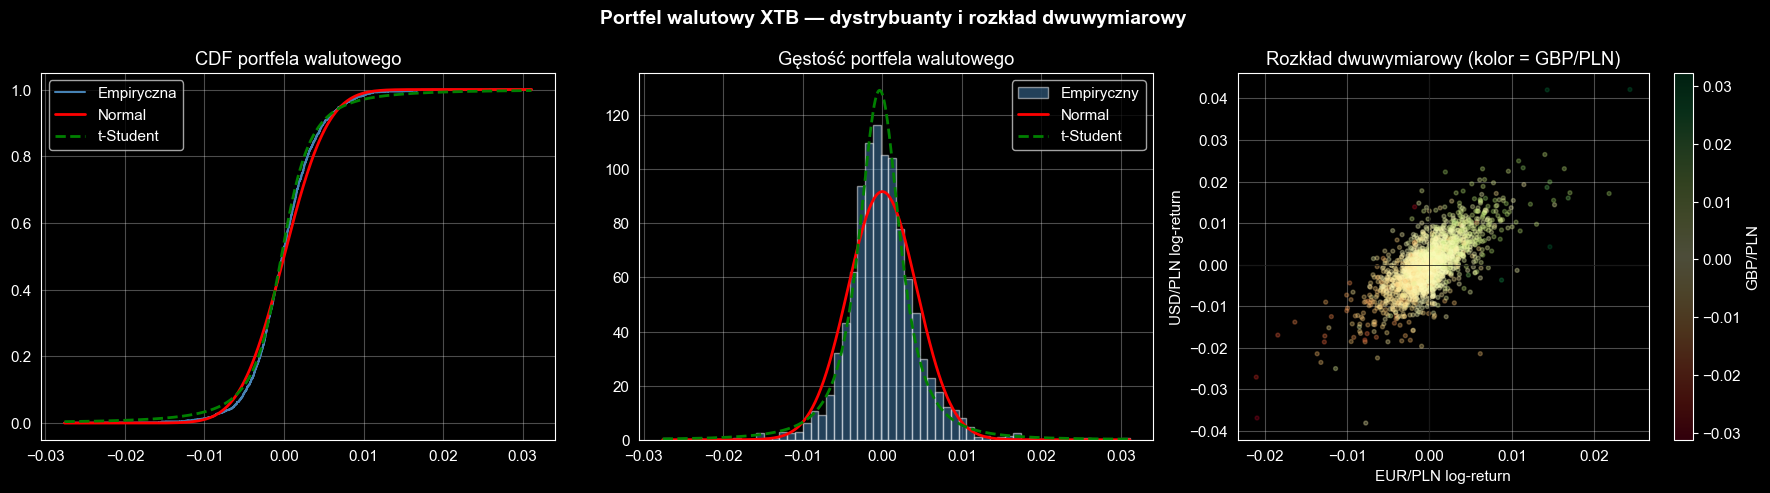


Dystrybuanta wielowymiarowa empiryczna F(x, x, x) = P(R_EUR ≤ x, R_USD ≤ x, R_GBP ≤ x):
(wszystkie waluty jednocześnie poniżej progu x)

  F(+0.000, +0.000, +0.000) = 0.3066  | Iloczyn marginalnych: 0.1332  | Stosunek: 2.30x
  F(-0.005, -0.005, -0.005) = 0.0345  | Iloczyn marginalnych: 0.0017  | Stosunek: 20.62x
  F(-0.010, -0.010, -0.010) = 0.0044  | Iloczyn marginalnych: 0.0000  | Stosunek: 420.09x
  F(-0.020, -0.020, -0.020) = 0.0010  | Iloczyn marginalnych: 0.0000  | Stosunek: 102921.03x


In [12]:
# ============================================================
# 2c. Dystrybuanta portfela + dystrybuanta wielowymiarowa
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Portfel walutowy XTB — dystrybuanty i rozkład dwuwymiarowy', fontsize=14, fontweight='bold')

# CDF portfela
ax = axes[0]
sorted_pr = np.sort(pr)
ecdf_p = np.arange(1, len(sorted_pr)+1) / len(sorted_pr)
x_grid_p = np.linspace(pr.min(), pr.max(), 500)
ax.step(sorted_pr, ecdf_p, color='steelblue', lw=1.5, label='Empiryczna')
ax.plot(x_grid_p, norm.cdf(x_grid_p, mu_p, sig_p), 'r-', lw=2, label='Normal')
ax.plot(x_grid_p, t_dist.cdf(x_grid_p, df_tp, loc_tp, scale_tp), 'g--', lw=2, label='t-Student')
ax.set_title('CDF portfela walutowego')
ax.legend()
ax.grid(alpha=0.3)

# Histogram portfela
ax = axes[1]
ax.hist(pr, bins=60, density=True, alpha=0.5, color='steelblue', label='Empiryczny')
ax.plot(x_grid_p, norm.pdf(x_grid_p, mu_p, sig_p), 'r-', lw=2, label='Normal')
ax.plot(x_grid_p, t_dist.pdf(x_grid_p, df_tp, loc_tp, scale_tp), 'g--', lw=2, label='t-Student')
ax.set_title('Gęstość portfela walutowego')
ax.legend()
ax.grid(alpha=0.3)

# Scatter plot dwuwymiarowy: EUR/PLN vs USD/PLN (dwie najważniejsze waluty)
ax = axes[2]
sc = ax.scatter(log_returns['EUR/PLN'], log_returns['USD/PLN'], 
                alpha=0.3, s=8, c=log_returns['GBP/PLN'], cmap='RdYlGn')
ax.set_xlabel('EUR/PLN log-return')
ax.set_ylabel('USD/PLN log-return')
ax.set_title('Rozkład dwuwymiarowy (kolor = GBP/PLN)')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)
plt.colorbar(sc, ax=ax, label='GBP/PLN')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Dystrybuanta wielowymiarowa: P(R_EUR ≤ x, R_USD ≤ x, R_GBP ≤ x)
print("\nDystrybuanta wielowymiarowa empiryczna F(x, x, x) = P(R_EUR ≤ x, R_USD ≤ x, R_GBP ≤ x):")
print("(wszystkie waluty jednocześnie poniżej progu x)\n")
thresholds = [0, -0.005, -0.01, -0.02]
for x in thresholds:
    mask = (log_returns[currency_cols] <= x).all(axis=1)
    f_multi = mask.mean()
    # Porównanie z iloczynem marginalnych (test niezależności)
    f_product = np.prod([np.mean(log_returns[c] <= x) for c in currency_cols])
    print(f"  F({x:+.3f}, {x:+.3f}, {x:+.3f}) = {f_multi:.4f}  "
          f"| Iloczyn marginalnych: {f_product:.4f}  "
          f"| Stosunek: {f_multi/f_product:.2f}x" if f_product > 0 else f"  F({x}) = {f_multi:.4f}")

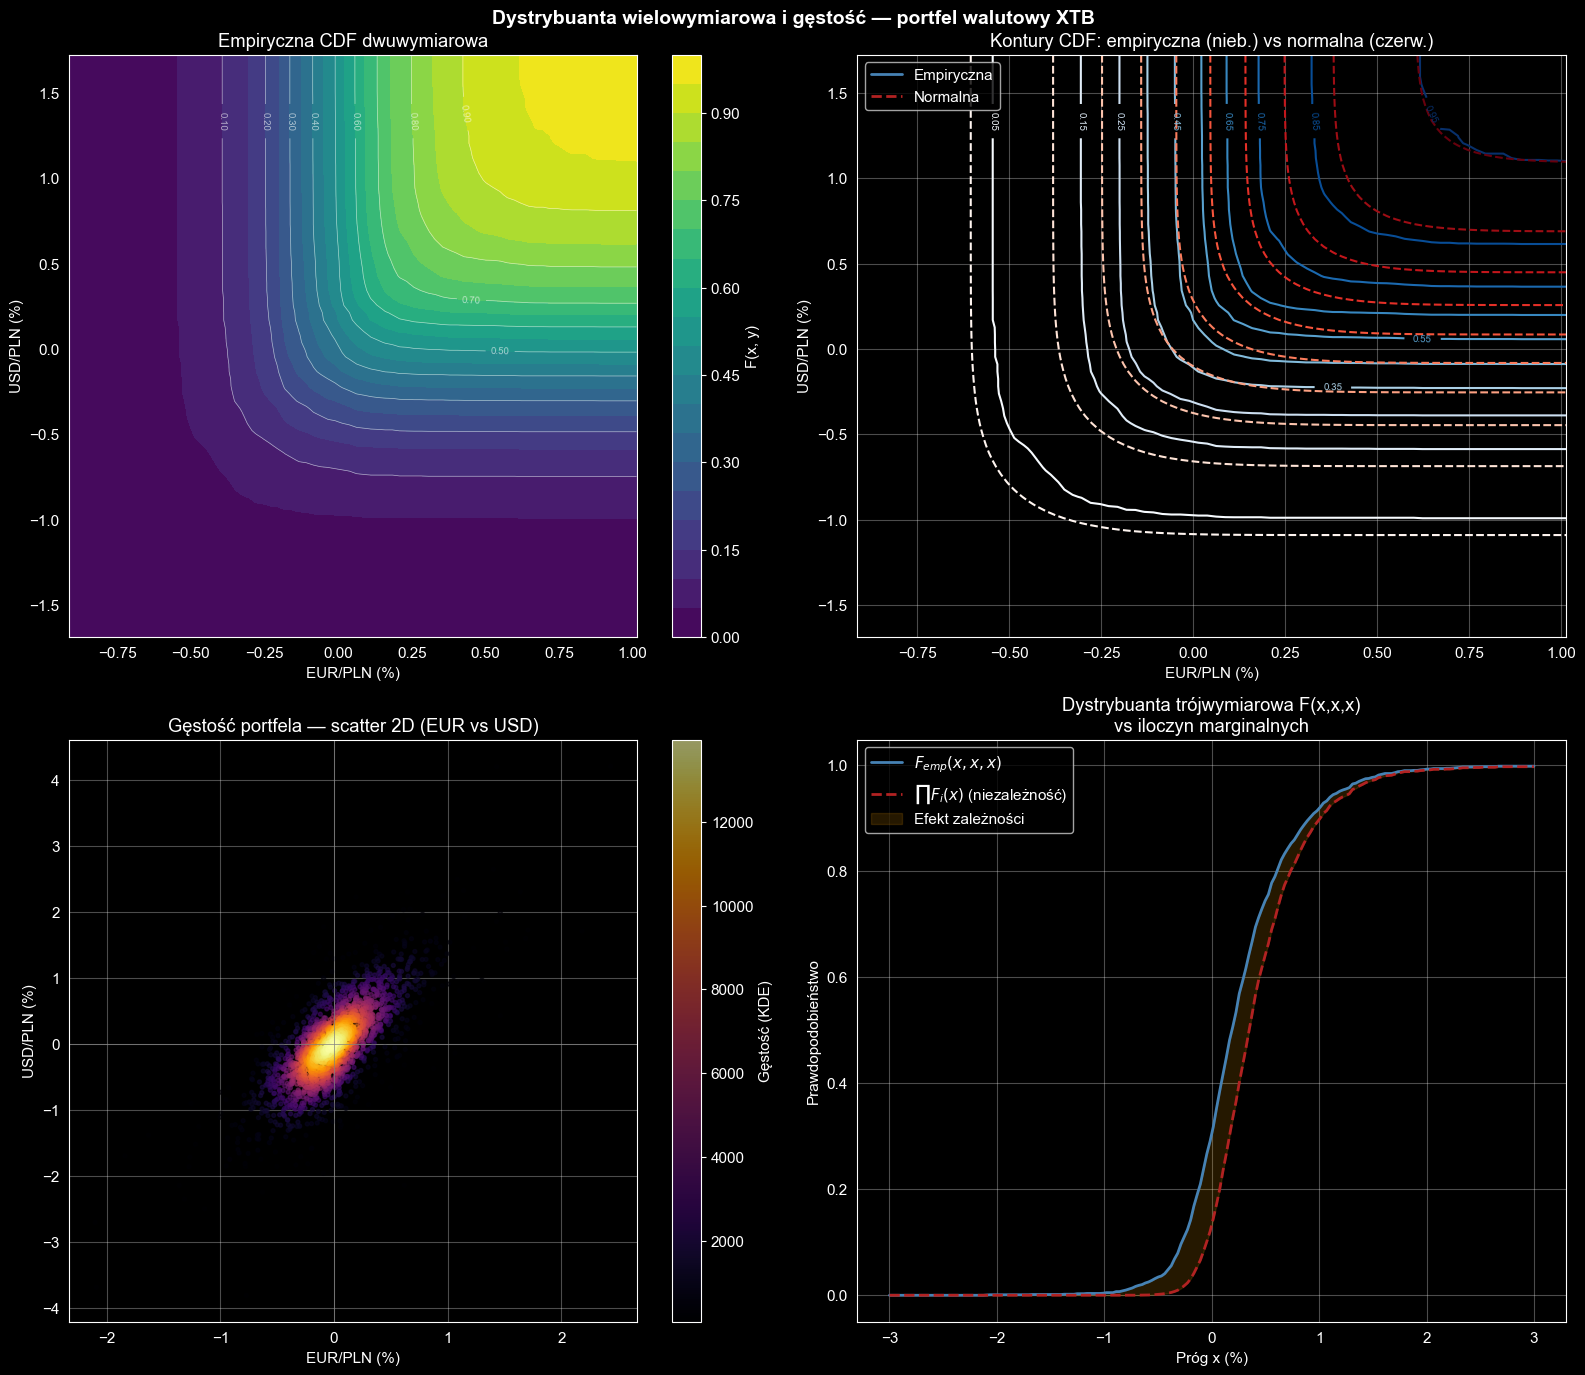

Interpretacja:
• Lewy górny: heatmapa empirycznej CDF łącznej P(R_EUR ≤ x, R_USD ≤ y)
• Prawy górny: kontury empirycznej vs normalnej CDF — różnice = odchylenia od gaussowskiej zależności
• Lewy dolny: scatter z kolorami wg gęstości KDE — widać skupienie i ogony rozkładu łącznego
• Prawy dolny: F(x,x,x) > ∏F_i(x) w lewym ogonie → jednoczesne spadki walut częstsze niż przy niezależności


In [13]:
# ============================================================
# 2c (cd). Wykresy dystrybuanty wielowymiarowej + gęstość portfela
# ============================================================
from scipy.stats import multivariate_normal, gaussian_kde

r_eur = log_returns['EUR/PLN'].values
r_usd = log_returns['USD/PLN'].values
r_gbp = log_returns['GBP/PLN'].values
n = len(r_eur)

# --- Siatka do wyliczenia F(x, y) = P(R_EUR ≤ x, R_USD ≤ y) ---
grid_size = 80
x_vals = np.linspace(np.percentile(r_eur, 1), np.percentile(r_eur, 99), grid_size)
y_vals = np.linspace(np.percentile(r_usd, 1), np.percentile(r_usd, 99), grid_size)
X, Y = np.meshgrid(x_vals, y_vals)

# Empiryczna CDF dwuwymiarowa
F_emp = np.zeros_like(X)
for i in range(grid_size):
    for j in range(grid_size):
        F_emp[i, j] = np.mean((r_eur <= X[i, j]) & (r_usd <= Y[i, j]))

# Teoretyczna CDF — rozkład normalny dwuwymiarowy
mean_2d = np.array([r_eur.mean(), r_usd.mean()])
cov_2d = np.cov(r_eur, r_usd)
mv_norm = multivariate_normal(mean=mean_2d, cov=cov_2d)
F_norm = np.zeros_like(X)
for i in range(grid_size):
    for j in range(grid_size):
        F_norm[i, j] = mv_norm.cdf([X[i, j], Y[i, j]])

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Dystrybuanta wielowymiarowa i gęstość — portfel walutowy XTB', fontsize=14, fontweight='bold')

# === Wykres 1: heatmapa empirycznej CDF ===
ax = axes[0, 0]
cf = ax.contourf(X * 100, Y * 100, F_emp, levels=20, cmap='viridis')
cs = ax.contour(X * 100, Y * 100, F_emp, levels=10, colors='white', linewidths=0.5, alpha=0.6)
ax.clabel(cs, fontsize=7, fmt='%.2f', colors='white')
plt.colorbar(cf, ax=ax, label='F(x, y)')
ax.set_xlabel('EUR/PLN (%)')
ax.set_ylabel('USD/PLN (%)')
ax.set_title('Empiryczna CDF dwuwymiarowa')
ax.grid(alpha=0.2)

# === Wykres 2: kontury empiryczna vs normalna ===
ax = axes[0, 1]
levels = np.arange(0.05, 1.0, 0.1)
from matplotlib.lines import Line2D
cs1 = ax.contour(X * 100, Y * 100, F_emp, levels=levels, cmap='Blues', linewidths=1.5)
cs2 = ax.contour(X * 100, Y * 100, F_norm, levels=levels, cmap='Reds', linewidths=1.5, linestyles='--')
ax.clabel(cs1, fontsize=7, fmt='%.2f')
ax.set_xlabel('EUR/PLN (%)')
ax.set_ylabel('USD/PLN (%)')
ax.set_title('Kontury CDF: empiryczna (nieb.) vs normalna (czerw.)')
ax.legend([Line2D([0],[0], color='steelblue', lw=2),
           Line2D([0],[0], color='firebrick', lw=2, ls='--')],
          ['Empiryczna', 'Normalna'], loc='upper left')
ax.grid(alpha=0.3)

# === Wykres 3: scatter gęstości portfela (EUR vs USD, kolor = KDE) ===
ax = axes[1, 0]
xy = np.vstack([r_eur, r_usd])
kde = gaussian_kde(xy)
density = kde(xy)
idx = density.argsort()  # sortowanie żeby najgęstsze punkty były na wierzchu
sc = ax.scatter(r_eur[idx] * 100, r_usd[idx] * 100, c=density[idx], s=8, alpha=0.6, cmap='inferno')
plt.colorbar(sc, ax=ax, label='Gęstość (KDE)')
ax.set_xlabel('EUR/PLN (%)')
ax.set_ylabel('USD/PLN (%)')
ax.set_title('Gęstość portfela — scatter 2D (EUR vs USD)')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.grid(alpha=0.3)

# === Wykres 4: F wielowymiarowa (3 waluty) jako funkcja progu ===
ax = axes[1, 1]
thresholds = np.linspace(-0.03, 0.03, 200)
f_3d_emp = np.array([np.mean((r_eur <= t) & (r_usd <= t) & (r_gbp <= t)) for t in thresholds])
f_product = np.array([np.mean(r_eur <= t) * np.mean(r_usd <= t) * np.mean(r_gbp <= t) for t in thresholds])

ax.plot(thresholds * 100, f_3d_emp, 'steelblue', lw=2, label=r'$F_{emp}(x, x, x)$')
ax.plot(thresholds * 100, f_product, 'firebrick', lw=2, ls='--', label=r'$\prod F_i(x)$ (niezależność)')
ax.fill_between(thresholds * 100, f_3d_emp, f_product, alpha=0.15, color='orange', label='Efekt zależności')
ax.set_xlabel('Próg x (%)')
ax.set_ylabel('Prawdopodobieństwo')
ax.set_title('Dystrybuanta trójwymiarowa F(x,x,x)\nvs iloczyn marginalnych')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretacja:")
print("• Lewy górny: heatmapa empirycznej CDF łącznej P(R_EUR ≤ x, R_USD ≤ y)")
print("• Prawy górny: kontury empirycznej vs normalnej CDF — różnice = odchylenia od gaussowskiej zależności")
print("• Lewy dolny: scatter z kolorami wg gęstości KDE — widać skupienie i ogony rozkładu łącznego")
print("• Prawy dolny: F(x,x,x) > ∏F_i(x) w lewym ogonie → jednoczesne spadki walut częstsze niż przy niezależności")

In [14]:
# ============================================================
# 2d. Porównanie: portfel vs poszczególne zmienne
# ============================================================

print("=" * 70)
print("2d. PORÓWNANIE — portfel vs poszczególne zmienne")
print("=" * 70)

comparison = []
# Poszczególne waluty
for col in currency_cols:
    r = log_returns[col].values
    comparison.append({
        'Zmienna': col,
        'σ dzienne': f'{r.std():.6f}',
        'σ roczne': f'{r.std()*np.sqrt(252):.4f}',
        'VaR 5% emp.': f'{np.percentile(r, 5):.6f}',
        'VaR 1% emp.': f'{np.percentile(r, 1):.6f}',
        'ES 5% emp.': f'{r[r <= np.percentile(r, 5)].mean():.6f}',
        'Skośność': f'{stats.skew(r):.4f}',
        'Kurtoza': f'{stats.kurtosis(r):.4f}',
    })

# Portfel
comparison.append({
    'Zmienna': 'PORTFEL',
    'σ dzienne': f'{pr.std():.6f}',
    'σ roczne': f'{pr.std()*np.sqrt(252):.4f}',
    'VaR 5% emp.': f'{np.percentile(pr, 5):.6f}',
    'VaR 1% emp.': f'{np.percentile(pr, 1):.6f}',
    'ES 5% emp.': f'{pr[pr <= np.percentile(pr, 5)].mean():.6f}',
    'Skośność': f'{stats.skew(pr):.4f}',
    'Kurtoza': f'{stats.kurtosis(pr):.4f}',
})

comp_df = pd.DataFrame(comparison)
print("\nPorównanie miar ryzyka — portfel powinien mieć niższe ryzyko dzięki dywersyfikacji:\n")
comp_df

2d. PORÓWNANIE — portfel vs poszczególne zmienne

Porównanie miar ryzyka — portfel powinien mieć niższe ryzyko dzięki dywersyfikacji:



,Zmienna,σ dzienne,σ roczne,VaR 5% emp.,VaR 1% emp.,ES 5% emp.,Skośność,Kurtoza
0,EUR/PLN,0.003675,0.0583,-0.005404,-0.009129,-0.007856,0.3367,4.4637
1,USD/PLN,0.006631,0.1053,-0.009889,-0.016859,-0.014267,0.1895,3.2181
2,GBP/PLN,0.005348,0.0849,-0.008398,-0.013596,-0.011991,0.0389,3.9804
3,PORTFEL,0.004348,0.0690,-0.006258,-0.010951,-0.009345,0.2872,4.1965


---
# 2e. Portfel CFD — Złoto, S&P 500, NASDAQ-100

XTB jako broker CFD generuje przychody prowizyjne i spreadowe od wolumenu transakcji klientów. Najpopularniejsze instrumenty CFD to:
- **Złoto (XAUUSD)** — safe haven, wysoka zmienność w okresach niepewności
- **S&P 500 (^GSPC)** — benchmark rynku amerykańskiego
- **NASDAQ-100 (^NDX)** — indeks technologiczny, najwyższa zmienność

**Wagi portfela** odzwierciedlają przybliżoną strukturę wolumenu CFD na platformie XTB:
- Złoto: 40% (najpopularniejszy instrument CFD)
- S&P 500: 35%
- NASDAQ-100: 25%

**Kluczowe pytanie:** Jak zmienność tych instrumentów wpływa na VaR portfela ekspozycji XTB i potencjalne zyski/straty spółki? Wyższa zmienność = wyższy spread + wolumen, ale też wyższe ryzyko sald ujemnych klientów.

In [15]:
# ============================================================
# 2e. Portfel CFD — pobieranie danych i budowa portfela
# ============================================================

cfd_tickers = {
    'GC=F':  'Złoto (XAU)',
    '^GSPC': 'S&P 500',
    '^NDX':  'NASDAQ-100'
}

cfd_data = yf.download(list(cfd_tickers.keys()), start='2022-01-01', end='2025-12-31')['Close']
cfd_data.columns = [cfd_tickers.get(c, c) for c in cfd_data.columns]
cfd_data = cfd_data.dropna()

cfd_returns = np.log(cfd_data / cfd_data.shift(1)).dropna()

# Wagi portfela CFD
cfd_cols = ['Złoto (XAU)', 'S&P 500', 'NASDAQ-100']
cfd_weights = np.array([0.40, 0.35, 0.25])

cfd_portfolio_returns = (cfd_returns[cfd_cols] * cfd_weights).sum(axis=1)

# Wspólny okres z portfelem walutowym
common_idx = cfd_portfolio_returns.index.intersection(portfolio_returns.index)
cfd_pr = cfd_portfolio_returns.loc[common_idx].values
fx_pr = portfolio_returns.loc[common_idx].values

print(f"Okres danych CFD: {cfd_data.index[0].date()} — {cfd_data.index[-1].date()}")
print(f"Obserwacje (log-returns): {len(cfd_returns)}")
print(f"Wspólny okres z portfelem walutowym: {len(common_idx)} dni")

print(f"\nStatystyki opisowe log-returns CFD (dzienne):")
cfd_returns.describe().T

[*********************100%***********************]  3 of 3 completed

Okres danych CFD: 2022-01-03 — 2025-12-30
Obserwacje (log-returns): 1001
Wspólny okres z portfelem walutowym: 969 dni

Statystyki opisowe log-returns CFD (dzienne):


,count,mean,std,min,25%,50%,75%,max
Złoto (XAU),1001.0,0.000886,0.010286,-0.059062,-0.004463,0.001084,0.006910,0.034368
S&P 500,1001.0,0.000363,0.011212,-0.061609,-0.005031,0.000641,0.006245,0.090895
NASDAQ-100,1001.0,0.000433,0.015037,-0.062593,-0.007333,0.001074,0.008724,0.113528


2e. PORTFEL CFD — MIARY RYZYKA

--- Macierz korelacji CFD ---


,Złoto (XAU),S&P 500,NASDAQ-100
Złoto (XAU),1.0000,0.0719,0.0580
S&P 500,0.0719,1.0000,0.9584
NASDAQ-100,0.0580,0.9584,1.0000



--- Zmienność portfela CFD ---
σ dzienne:       0.008876
σ roczne:        0.1409
Redukcja ryzyka przez dywersyfikację: 24.8%

--- VaR i ES portfela CFD ---


,α,VaR emp.,VaR Normal,VaR t-Student,ES emp.
0,1%,-0.023079,-0.020058,-0.022243,-0.030226
1,5%,-0.013924,-0.014009,-0.012829,-0.020008
2,10%,-0.010095,-0.010785,-0.009128,-0.015991



PORÓWNANIE: portfel CFD vs portfel walutowy


,σ dzienne,σ roczne,Średnia dz.,VaR 1%,VaR 5%,ES 1%,Skośność,Kurtoza
Portfel,,,,,,,,
Walutowy (FX),0.004794,0.0761,-0.000082,-0.011048,-0.006866,-0.016362,0.3074,4.2680
CFD,0.008921,0.1416,0.000572,-0.023294,-0.013997,-0.030941,0.0828,6.1550



--- Zmienność poszczególnych instrumentów (σ roczne) ---


,Typ,σ roczne,Kurtoza
Instrument,,,
EUR/PLN,FX,0.0583,4.46
USD/PLN,FX,0.1053,3.22
GBP/PLN,FX,0.0849,3.98
Złoto (XAU),CFD,0.1632,2.29
S&P 500,CFD,0.1779,6.44
NASDAQ-100,CFD,0.2386,4.38


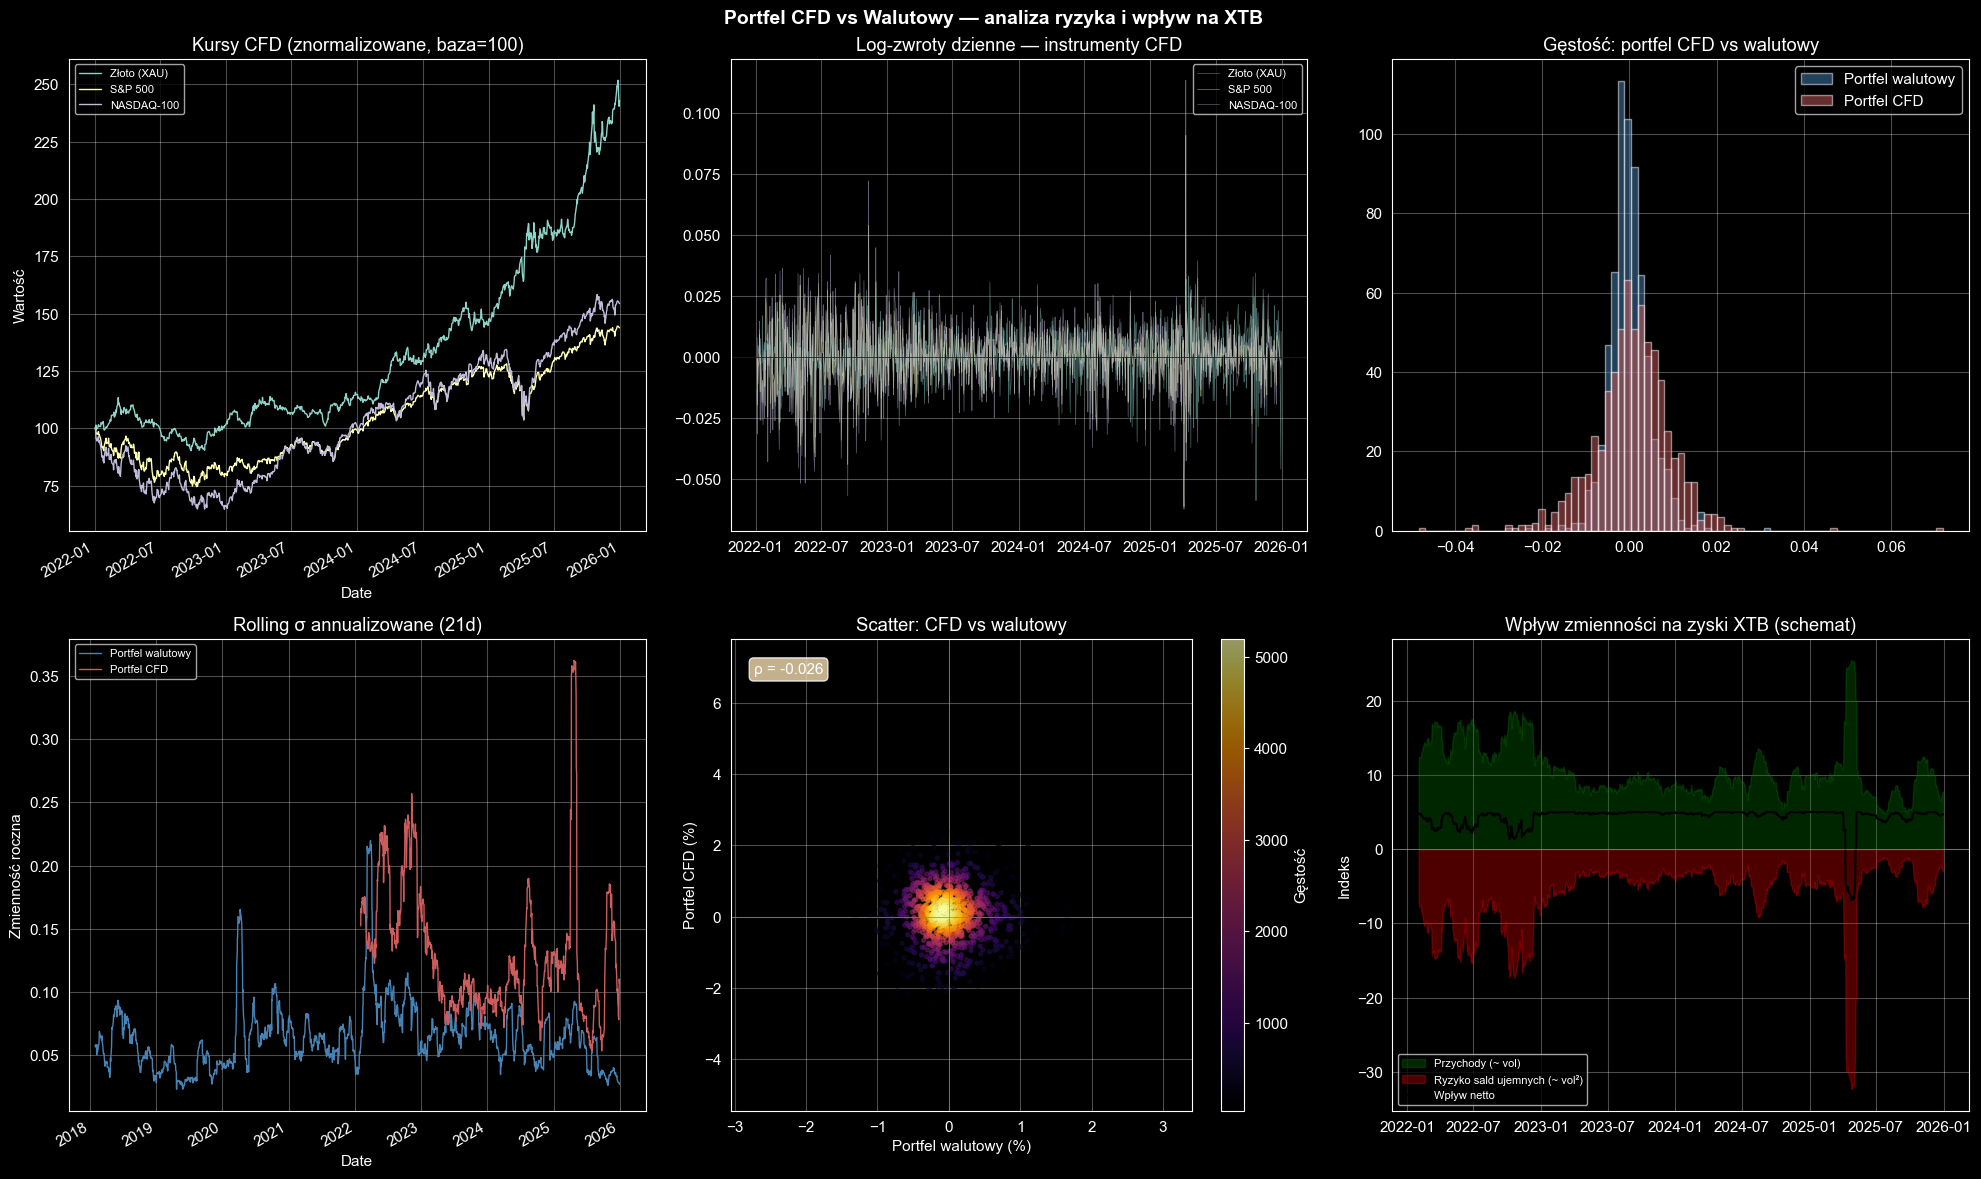


--- Interpretacja wpływu na XTB ---
• Zmienność portfela CFD jest 2.0x wyższa niż portfela walutowego
• Korelacja między portfelami: ρ = -0.026
  → Niska korelacja — dywersyfikacja źródeł ryzyka XTB
• VaR 1% portfela CFD (-2.33%) vs walutowego (-1.10%)
  → CFD generuje większe ryzyko ekstremalnych strat
• Dla XTB: wysoka zmienność CFD to miecz obosieczny:
  - ZYSK: wyższy vol → wyższe spready, więcej transakcji klientów, wyższe prowizje
  - RYZYKO: wyższy vol → więcej sald ujemnych klientów, wyższe wymogi kapitałowe (KNF)
  - Optymalny zakres zmienności: umiarkowany vol maksymalizuje zysk netto


In [16]:
# ============================================================
# 2e (cd). Analiza ryzyka portfela CFD + porównanie z walutowym
# ============================================================
from scipy.stats import gaussian_kde

# --- Macierz korelacji i kowariancji CFD ---
cfd_cov = cfd_returns[cfd_cols].cov()
cfd_corr = cfd_returns[cfd_cols].corr()

print("=" * 70)
print("2e. PORTFEL CFD — MIARY RYZYKA")
print("=" * 70)

print("\n--- Macierz korelacji CFD ---")
display(cfd_corr.round(4))

# --- Zmienność ---
cfd_pr_all = cfd_portfolio_returns.values
sigma_cfd = cfd_pr_all.std()
sigma_cfd_ann = sigma_cfd * np.sqrt(252)

sum_weighted_sigmas_cfd = sum(w * cfd_returns[c].std() for w, c in zip(cfd_weights, cfd_cols))
diversification_cfd = (1 - sigma_cfd / sum_weighted_sigmas_cfd) * 100

print(f"\n--- Zmienność portfela CFD ---")
print(f"σ dzienne:       {sigma_cfd:.6f}")
print(f"σ roczne:        {sigma_cfd_ann:.4f}")
print(f"Redukcja ryzyka przez dywersyfikację: {diversification_cfd:.1f}%")

# --- VaR i ES ---
mu_cfd, sig_cfd = cfd_pr_all.mean(), cfd_pr_all.std()
df_cfd, loc_cfd, scale_cfd = t_dist.fit(cfd_pr_all)

print(f"\n--- VaR i ES portfela CFD ---")
cfd_var_rows = []
for alpha in [0.01, 0.05, 0.10]:
    var_emp = np.percentile(cfd_pr_all, alpha * 100)
    var_norm = norm.ppf(alpha, loc=mu_cfd, scale=sig_cfd)
    var_t = t_dist.ppf(alpha, df_cfd, loc=loc_cfd, scale=scale_cfd)
    es_emp = cfd_pr_all[cfd_pr_all <= var_emp].mean()
    cfd_var_rows.append({
        'α': f'{alpha:.0%}',
        'VaR emp.': f'{var_emp:.6f}',
        'VaR Normal': f'{var_norm:.6f}',
        'VaR t-Student': f'{var_t:.6f}',
        'ES emp.': f'{es_emp:.6f}',
    })
display(pd.DataFrame(cfd_var_rows))

# ============================================================
# PORÓWNANIE: portfel CFD vs portfel walutowy
# ============================================================
print("\n" + "=" * 70)
print("PORÓWNANIE: portfel CFD vs portfel walutowy")
print("=" * 70)

comp_portfolios = []
for name, ret, w, cols, ret_df in [
    ('Walutowy (FX)', fx_pr, weights, currency_cols, log_returns),
    ('CFD', cfd_pr, cfd_weights, cfd_cols, cfd_returns)
]:
    comp_portfolios.append({
        'Portfel': name,
        'σ dzienne': f'{ret.std():.6f}',
        'σ roczne': f'{ret.std()*np.sqrt(252):.4f}',
        'Średnia dz.': f'{ret.mean():.6f}',
        'VaR 1%': f'{np.percentile(ret, 1):.6f}',
        'VaR 5%': f'{np.percentile(ret, 5):.6f}',
        'ES 1%': f'{ret[ret <= np.percentile(ret, 1)].mean():.6f}',
        'Skośność': f'{stats.skew(ret):.4f}',
        'Kurtoza': f'{stats.kurtosis(ret):.4f}',
    })
display(pd.DataFrame(comp_portfolios).set_index('Portfel'))

# --- Zmienność poszczególnych instrumentów CFD vs waluty ---
print("\n--- Zmienność poszczególnych instrumentów (σ roczne) ---")
vol_rows = []
for col in currency_cols:
    r = log_returns[col].dropna().values
    vol_rows.append({'Instrument': col, 'Typ': 'FX', 'σ roczne': f'{r.std()*np.sqrt(252):.4f}',
                     'Kurtoza': f'{stats.kurtosis(r):.2f}'})
for col in cfd_cols:
    r = cfd_returns[col].dropna().values
    vol_rows.append({'Instrument': col, 'Typ': 'CFD', 'σ roczne': f'{r.std()*np.sqrt(252):.4f}',
                     'Kurtoza': f'{stats.kurtosis(r):.2f}'})
display(pd.DataFrame(vol_rows).set_index('Instrument'))

# ============================================================
# WYKRESY
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Portfel CFD vs Walutowy — analiza ryzyka i wpływ na XTB', fontsize=14, fontweight='bold')

# 1) Kursy zamknięcia CFD (znormalizowane)
ax = axes[0, 0]
for col in cfd_cols:
    (cfd_data[col] / cfd_data[col].iloc[0] * 100).plot(ax=ax, lw=1)
ax.set_title('Kursy CFD (znormalizowane, baza=100)')
ax.set_ylabel('Wartość')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2) Log-zwroty CFD
ax = axes[0, 1]
for i, col in enumerate(cfd_cols):
    ax.plot(cfd_returns.index, cfd_returns[col], alpha=0.5, lw=0.5, label=col)
ax.set_title('Log-zwroty dzienne — instrumenty CFD')
ax.axhline(0, color='black', lw=0.5)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 3) Porównanie rozkładów: portfel CFD vs FX
ax = axes[0, 2]
bins = np.linspace(min(cfd_pr.min(), fx_pr.min()), max(cfd_pr.max(), fx_pr.max()), 80)
ax.hist(fx_pr, bins=bins, density=True, alpha=0.5, color='steelblue', label='Portfel walutowy')
ax.hist(cfd_pr, bins=bins, density=True, alpha=0.5, color='indianred', label='Portfel CFD')
ax.set_title('Gęstość: portfel CFD vs walutowy')
ax.legend()
ax.grid(alpha=0.3)

# 4) Rolling volatility (21d) — porównanie
ax = axes[1, 0]
window = 21
cfd_roll_vol = pd.Series(cfd_pr_all, index=cfd_portfolio_returns.index).rolling(window).std() * np.sqrt(252)
fx_roll_vol = portfolio_returns.rolling(window).std() * np.sqrt(252)
fx_roll_vol.plot(ax=ax, color='steelblue', lw=1, label='Portfel walutowy')
cfd_roll_vol.plot(ax=ax, color='indianred', lw=1, label='Portfel CFD')
ax.set_title(f'Rolling σ annualizowane ({window}d)')
ax.set_ylabel('Zmienność roczna')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 5) Scatter: zwroty CFD vs FX (wspólny okres)
ax = axes[1, 1]
xy = np.vstack([fx_pr, cfd_pr])
kde = gaussian_kde(xy)
density = kde(xy)
idx = density.argsort()
sc = ax.scatter(fx_pr[idx] * 100, cfd_pr[idx] * 100, c=density[idx], s=8, alpha=0.6, cmap='inferno')
plt.colorbar(sc, ax=ax, label='Gęstość')
ax.set_xlabel('Portfel walutowy (%)')
ax.set_ylabel('Portfel CFD (%)')
ax.set_title('Scatter: CFD vs walutowy')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
rho = np.corrcoef(fx_pr, cfd_pr)[0, 1]
ax.text(0.05, 0.95, f'ρ = {rho:.3f}', transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.grid(alpha=0.3)

# 6) Wpływ zmienności na przychody XTB — symulacja
ax = axes[1, 2]
# Przychody XTB ~ f(zmienności) — wyższy vol = wyższy spread income ale wyższe ryzyko
combined_vol = 0.6 * cfd_roll_vol + 0.4 * fx_roll_vol  # ważona zmienność obu portfeli
combined_vol = combined_vol.dropna()
# Symulacja: przychód = vol * volume_factor - straty z sald ujemnych
revenue_proxy = combined_vol * 100  # indeks przychodów (proporcjonalny do vol)
risk_proxy = combined_vol ** 2 * 500  # ryzyko rośnie kwadratowo
net = revenue_proxy - risk_proxy

ax.fill_between(combined_vol.index, 0, revenue_proxy, alpha=0.3, color='green', label='Przychody (~ vol)')
ax.fill_between(combined_vol.index, 0, -risk_proxy, alpha=0.3, color='red', label='Ryzyko sald ujemnych (~ vol²)')
ax.plot(combined_vol.index, net, color='black', lw=1.5, label='Wpływ netto')
ax.axhline(0, color='grey', lw=0.5)
ax.set_title('Wpływ zmienności na zyski XTB (schemat)')
ax.set_ylabel('Indeks')
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Interpretacja ---
print("\n--- Interpretacja wpływu na XTB ---")
vol_ratio = cfd_pr_all.std() / portfolio_returns.std()
print(f"• Zmienność portfela CFD jest {vol_ratio:.1f}x wyższa niż portfela walutowego")
print(f"• Korelacja między portfelami: ρ = {rho:.3f}")
print(f"  → {'Niska korelacja — dywersyfikacja źródeł ryzyka XTB' if abs(rho) < 0.3 else 'Umiarkowana/wysoka korelacja — ryzyko się kumuluje'}")
print(f"• VaR 1% portfela CFD ({np.percentile(cfd_pr, 1)*100:.2f}%) vs walutowego ({np.percentile(fx_pr, 1)*100:.2f}%)")
print(f"  → CFD generuje {'większe' if abs(np.percentile(cfd_pr, 1)) > abs(np.percentile(fx_pr, 1)) else 'mniejsze'} ryzyko ekstremalnych strat")
print(f"• Dla XTB: wysoka zmienność CFD to miecz obosieczny:")
print(f"  - ZYSK: wyższy vol → wyższe spready, więcej transakcji klientów, wyższe prowizje")
print(f"  - RYZYKO: wyższy vol → więcej sald ujemnych klientów, wyższe wymogi kapitałowe (KNF)")
print(f"  - Optymalny zakres zmienności: umiarkowany vol maksymalizuje zysk netto")

2f. PORTFEL FX SPOT vs CFD NA WALUTY (lewar 5:1)

--- Porównanie miar ryzyka ---


,σ dzienne,σ roczne,Średnia dz.,VaR 1% emp.,VaR 5% emp.,ES 1% emp.,ES 5% emp.,Max strata dz.,Skośność,Kurtoza
Portfel,,,,,,,,,,
FX spot (1:1),0.004348,0.0690,0.000010,-0.010951,-0.006258,-0.014512,-0.009345,-0.027599,0.2872,4.1965
CFD walutowy (5:1),0.021738,0.3451,0.000051,-0.054755,-0.031292,-0.072559,-0.046724,-0.137996,0.2872,4.1965



--- VaR i ES: spot vs lewar 5:1 ---


,α,VaR spot,VaR CFD 5:1,Mnożnik,ES spot,ES CFD 5:1
0,1%,-1.095%,-5.475%,5.0x,-1.451%,-7.256%
1,5%,-0.626%,-3.129%,5.0x,-0.934%,-4.672%
2,10%,-0.471%,-2.353%,5.0x,-0.739%,-3.693%



--- Ryzyko margin call i sald ujemnych (lewar 5:1) ---
Depozyt (margin): 20% wartości pozycji
Margin call (strata ≥ 10% depozytu):  2 dni (0.10%)
Saldo ujemne (strata ≥ 20% depozytu): 0 dni (0.00%)


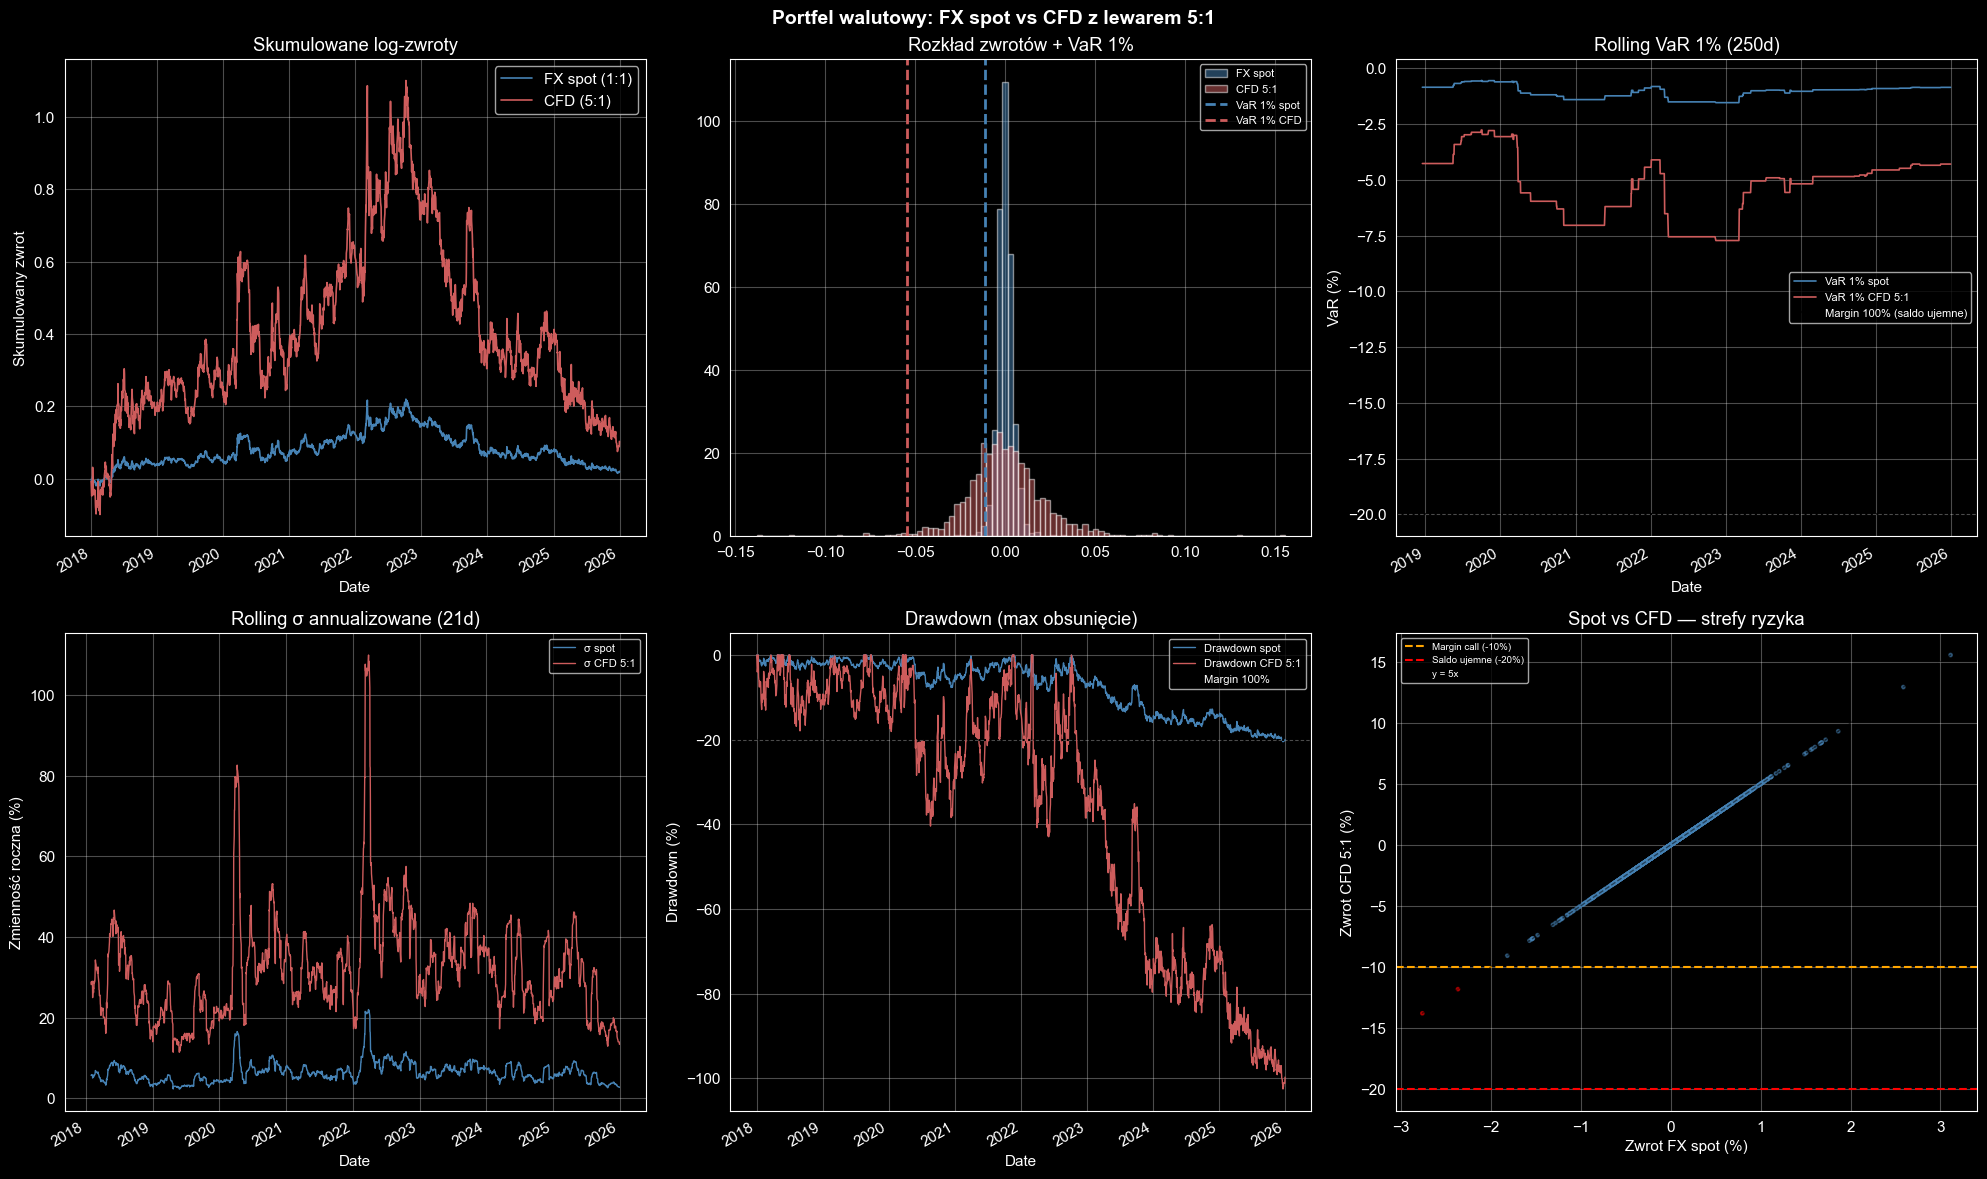


--- Interpretacja: lewar 5:1 na walutach XTB ---
• Lewar 5:1 mnoży zmienność 5x: σ spot = 0.435% → σ CFD = 2.174%
• VaR 1% rośnie z -1.095% do -5.475%
• Max drawdown CFD: -102.52% vs spot: -20.50%
• Margin call events: 2 dni — to sytuacje, gdy XTB musi zamknąć pozycje klientów
• Saldo ujemne: 0 dni — XTB ponosi stratę (ochrona przed saldem ujemnym wg ESMA)
• Dla XTB jako brokera: lewar zwiększa wolumen transakcji (= przychody),
  ale wymaga wyższych buforów kapitałowych na pokrycie ryzyka sald ujemnych


In [17]:
# ============================================================
# 2f. Porównanie: portfel FX spot vs CFD na waluty z lewarem 5:1
# ============================================================
# Na XTB klienci handlują CFD na waluty z lewarem (dźwignią).
# Lewar 5:1 oznacza, że klient wpłaca 20% wartości pozycji jako depozyt (margin).
# Stopy zwrotu z lewarem: R_lev = lewar × R_spot
# VaR i ES rosną proporcjonalnie do lewara.

leverage = 5

# Stopy zwrotu z lewarem (te same waluty, te same wagi)
leveraged_returns = portfolio_returns * leverage
lev_pr = leveraged_returns.values

# Dopasowanie rozkładów
mu_lev, sig_lev = lev_pr.mean(), lev_pr.std()
df_lev, loc_lev, scale_lev = t_dist.fit(lev_pr)

print("=" * 70)
print(f"2f. PORTFEL FX SPOT vs CFD NA WALUTY (lewar {leverage}:1)")
print("=" * 70)

# --- Tabela porównawcza ---
comp_lev = []
for name, ret in [('FX spot (1:1)', portfolio_returns.values), (f'CFD walutowy ({leverage}:1)', lev_pr)]:
    r = ret
    comp_lev.append({
        'Portfel': name,
        'σ dzienne': f'{r.std():.6f}',
        'σ roczne': f'{r.std()*np.sqrt(252):.4f}',
        'Średnia dz.': f'{r.mean():.6f}',
        'VaR 1% emp.': f'{np.percentile(r, 1):.6f}',
        'VaR 5% emp.': f'{np.percentile(r, 5):.6f}',
        'ES 1% emp.': f'{r[r <= np.percentile(r, 1)].mean():.6f}',
        'ES 5% emp.': f'{r[r <= np.percentile(r, 5)].mean():.6f}',
        'Max strata dz.': f'{r.min():.6f}',
        'Skośność': f'{stats.skew(r):.4f}',
        'Kurtoza': f'{stats.kurtosis(r):.4f}',
    })

print("\n--- Porównanie miar ryzyka ---")
display(pd.DataFrame(comp_lev).set_index('Portfel'))

# --- VaR / ES szczegółowo ---
print(f"\n--- VaR i ES: spot vs lewar {leverage}:1 ---")
var_lev_rows = []
for alpha in [0.01, 0.05, 0.10]:
    var_spot = np.percentile(portfolio_returns.values, alpha * 100)
    var_lev = np.percentile(lev_pr, alpha * 100)
    es_spot = portfolio_returns.values[portfolio_returns.values <= var_spot].mean()
    es_lev = lev_pr[lev_pr <= var_lev].mean()
    # Margin call: strata > 100% depozytu (depozyt = 1/lewar = 20%)
    var_lev_rows.append({
        'α': f'{alpha:.0%}',
        'VaR spot': f'{var_spot*100:.3f}%',
        f'VaR CFD {leverage}:1': f'{var_lev*100:.3f}%',
        'Mnożnik': f'{var_lev/var_spot:.1f}x',
        'ES spot': f'{es_spot*100:.3f}%',
        f'ES CFD {leverage}:1': f'{es_lev*100:.3f}%',
    })
display(pd.DataFrame(var_lev_rows))

# --- Ryzyko margin call i sald ujemnych ---
margin = 1 / leverage  # 20% dla lewara 5:1
margin_call_threshold = -margin * 0.5  # margin call przy 50% utraty depozytu
negative_balance_threshold = -margin  # saldo ujemne przy 100% utraty depozytu

n_days = len(lev_pr)
margin_call_days = np.sum(lev_pr <= margin_call_threshold)
negative_balance_days = np.sum(lev_pr <= negative_balance_threshold)

print(f"\n--- Ryzyko margin call i sald ujemnych (lewar {leverage}:1) ---")
print(f"Depozyt (margin): {margin*100:.0f}% wartości pozycji")
print(f"Margin call (strata ≥ {abs(margin_call_threshold)*100:.0f}% depozytu):  "
      f"{margin_call_days} dni ({margin_call_days/n_days*100:.2f}%)")
print(f"Saldo ujemne (strata ≥ {abs(negative_balance_threshold)*100:.0f}% depozytu): "
      f"{negative_balance_days} dni ({negative_balance_days/n_days*100:.2f}%)")

# ============================================================
# WYKRESY
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'Portfel walutowy: FX spot vs CFD z lewarem {leverage}:1', fontsize=14, fontweight='bold')

# 1) Porównanie zwrotów w czasie
ax = axes[0, 0]
portfolio_returns.cumsum().plot(ax=ax, color='steelblue', lw=1.2, label='FX spot (1:1)')
leveraged_returns.cumsum().plot(ax=ax, color='indianred', lw=1.2, label=f'CFD ({leverage}:1)')
ax.set_title('Skumulowane log-zwroty')
ax.set_ylabel('Skumulowany zwrot')
ax.legend()
ax.grid(alpha=0.3)

# 2) Histogram porównawczy
ax = axes[0, 1]
bins_range = np.linspace(min(lev_pr.min(), portfolio_returns.min()), 
                         max(lev_pr.max(), portfolio_returns.max()), 100)
ax.hist(portfolio_returns.values, bins=bins_range, density=True, alpha=0.5, color='steelblue', label='FX spot')
ax.hist(lev_pr, bins=bins_range, density=True, alpha=0.5, color='indianred', label=f'CFD {leverage}:1')
# Linie VaR 1%
ax.axvline(np.percentile(portfolio_returns.values, 1), color='steelblue', ls='--', lw=2, label=f'VaR 1% spot')
ax.axvline(np.percentile(lev_pr, 1), color='indianred', ls='--', lw=2, label=f'VaR 1% CFD')
ax.set_title('Rozkład zwrotów + VaR 1%')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 3) Rolling VaR 1% (250d)
ax = axes[0, 2]
roll_w = 250
spot_series = pd.Series(portfolio_returns.values, index=portfolio_returns.index)
lev_series = pd.Series(lev_pr, index=portfolio_returns.index)
rolling_var_spot = spot_series.rolling(roll_w).quantile(0.01)
rolling_var_lev = lev_series.rolling(roll_w).quantile(0.01)
(rolling_var_spot * 100).plot(ax=ax, color='steelblue', lw=1.2, label='VaR 1% spot')
(rolling_var_lev * 100).plot(ax=ax, color='indianred', lw=1.2, label=f'VaR 1% CFD {leverage}:1')
ax.axhline(-margin * 100, color='black', ls=':', lw=1.5, label=f'Margin 100% (saldo ujemne)')
ax.set_title(f'Rolling VaR 1% ({roll_w}d)')
ax.set_ylabel('VaR (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 4) Rolling volatility porównanie
ax = axes[1, 0]
window = 21
(spot_series.rolling(window).std() * np.sqrt(252) * 100).plot(ax=ax, color='steelblue', lw=1, label='σ spot')
(lev_series.rolling(window).std() * np.sqrt(252) * 100).plot(ax=ax, color='indianred', lw=1, label=f'σ CFD {leverage}:1')
ax.set_title(f'Rolling σ annualizowane ({window}d)')
ax.set_ylabel('Zmienność roczna (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 5) Drawdown
ax = axes[1, 1]
cum_spot = spot_series.cumsum()
cum_lev = lev_series.cumsum()
dd_spot = cum_spot - cum_spot.cummax()
dd_lev = cum_lev - cum_lev.cummax()
(dd_spot * 100).plot(ax=ax, color='steelblue', lw=1, label='Drawdown spot')
(dd_lev * 100).plot(ax=ax, color='indianred', lw=1, label=f'Drawdown CFD {leverage}:1')
ax.axhline(-margin * 100, color='black', ls=':', lw=1.5, label='Margin 100%')
ax.set_title('Drawdown (max obsunięcie)')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 6) Scatter spot vs lewar z zaznaczeniem stref ryzyka
ax = axes[1, 2]
colors_sc = np.where(lev_pr <= margin_call_threshold, 'red',
             np.where(lev_pr <= negative_balance_threshold, 'darkred', 'steelblue'))
ax.scatter(portfolio_returns.values * 100, lev_pr * 100, c=colors_sc, s=6, alpha=0.5)
ax.axhline(margin_call_threshold * 100, color='orange', ls='--', lw=1.5, label=f'Margin call ({margin_call_threshold*100:.0f}%)')
ax.axhline(negative_balance_threshold * 100, color='red', ls='--', lw=1.5, label=f'Saldo ujemne ({negative_balance_threshold*100:.0f}%)')
ax.plot([portfolio_returns.min()*100, portfolio_returns.max()*100],
        [portfolio_returns.min()*100*leverage, portfolio_returns.max()*100*leverage],
        'k--', lw=1, alpha=0.5, label=f'y = {leverage}x')
ax.set_xlabel('Zwrot FX spot (%)')
ax.set_ylabel(f'Zwrot CFD {leverage}:1 (%)')
ax.set_title(f'Spot vs CFD — strefy ryzyka')
ax.legend(fontsize=7, loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Interpretacja ---
print(f"\n--- Interpretacja: lewar {leverage}:1 na walutach XTB ---")
print(f"• Lewar {leverage}:1 mnoży zmienność {leverage}x: σ spot = {portfolio_returns.std()*100:.3f}% → σ CFD = {lev_pr.std()*100:.3f}%")
print(f"• VaR 1% rośnie z {np.percentile(portfolio_returns.values, 1)*100:.3f}% do {np.percentile(lev_pr, 1)*100:.3f}%")
print(f"• Max drawdown CFD: {dd_lev.min()*100:.2f}% vs spot: {dd_spot.min()*100:.2f}%")
print(f"• Margin call events: {margin_call_days} dni — to sytuacje, gdy XTB musi zamknąć pozycje klientów")
print(f"• Saldo ujemne: {negative_balance_days} dni — XTB ponosi stratę (ochrona przed saldem ujemnym wg ESMA)")
print(f"• Dla XTB jako brokera: lewar zwiększa wolumen transakcji (= przychody),")
print(f"  ale wymaga wyższych buforów kapitałowych na pokrycie ryzyka sald ujemnych")

---
# 3. Ryzyko ekstremalne (EVT — Extreme Value Theory)

Dla zmiennej **XTB.WA** (cena akcji) stosujemy dwa podejścia:
- **Block Maxima (GEV):** dzielimy dane na bloki miesięczne, bierzemy maksima strat → dopasowujemy rozkład GEV
- **Peaks Over Threshold (GPD):** bierzemy straty przekraczające wysoki próg (kwantyl 95%) → dopasowujemy uogólniony rozkład Pareto (GPD)

Obie metody pozwalają modelować ogon rozkładu strat i estymować VaR/ES dla ekstremalnie niskich prawdopodobieństw.

3. RYZYKO EKSTREMALNE — XTB.WA

--- 3a. Block Maxima (GEV) ---
Liczba bloków (miesięcy): 96
Parametry GEV: ξ (shape)=-0.3863, μ (loc)=0.035019, σ (scale)=0.017235
ξ < 0 → rozkład Weibulla (ogon ograniczony)
ξ = 0 → rozkład Gumbela
ξ > 0 → rozkład Frécheta (ogon ciężki)
  VaR (strata) 95.0% z GEV: 0.13095 (13.09%)
  VaR (strata) 99.0% z GEV: 0.25421 (25.42%)
  VaR (strata) 99.9% z GEV: 0.63366 (63.37%)


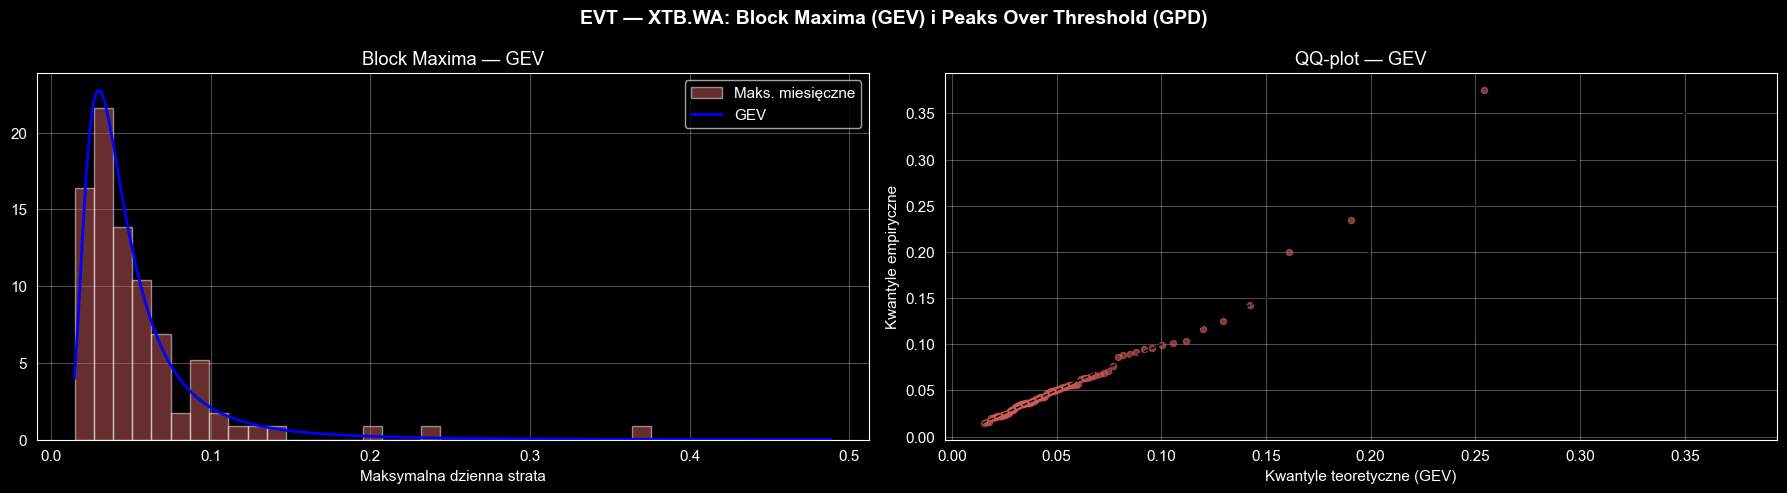

In [18]:
# ============================================================
# 3a. EVT — Block Maxima (GEV) dla XTB.WA
# ============================================================

losses_xtb = -log_returns['XTB.WA']  # straty = ujemne stopy zwrotu

# Block Maxima — maksymalne dzienne straty w każdym miesiącu
losses_monthly_max = losses_xtb.resample('ME').max().dropna()

# Dopasowanie GEV (Generalized Extreme Value)
gev_params = genextreme.fit(losses_monthly_max)
c_gev, loc_gev, scale_gev = gev_params

print("=" * 70)
print("3. RYZYKO EKSTREMALNE — XTB.WA")
print("=" * 70)

print(f"\n--- 3a. Block Maxima (GEV) ---")
print(f"Liczba bloków (miesięcy): {len(losses_monthly_max)}")
print(f"Parametry GEV: ξ (shape)={c_gev:.4f}, μ (loc)={loc_gev:.6f}, σ (scale)={scale_gev:.6f}")
print(f"ξ < 0 → rozkład Weibulla (ogon ograniczony)")
print(f"ξ = 0 → rozkład Gumbela")
print(f"ξ > 0 → rozkład Frécheta (ogon ciężki)")

# VaR z GEV
for p in [0.95, 0.99, 0.999]:
    var_gev = genextreme.ppf(p, c_gev, loc=loc_gev, scale=scale_gev)
    print(f"  VaR (strata) {p:.1%} z GEV: {var_gev:.5f} ({var_gev*100:.2f}%)")

# Wykres
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('EVT — XTB.WA: Block Maxima (GEV) i Peaks Over Threshold (GPD)', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(losses_monthly_max, bins=30, density=True, alpha=0.5, color='indianred', label='Maks. miesięczne')
x_gev = np.linspace(losses_monthly_max.min(), losses_monthly_max.max()*1.3, 200)
ax.plot(x_gev, genextreme.pdf(x_gev, *gev_params), 'b-', lw=2, label='GEV')
ax.set_title('Block Maxima — GEV')
ax.set_xlabel('Maksymalna dzienna strata')
ax.legend()
ax.grid(alpha=0.3)

# QQ-plot GEV
ax = axes[1]
theoretical_q = genextreme.ppf(np.linspace(0.01, 0.99, len(losses_monthly_max)), *gev_params)
empirical_q = np.sort(losses_monthly_max.values)
ax.scatter(theoretical_q, empirical_q, alpha=0.6, s=20, color='indianred')
lims = [min(theoretical_q.min(), empirical_q.min()), max(theoretical_q.max(), empirical_q.max())]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('Kwantyle teoretyczne (GEV)')
ax.set_ylabel('Kwantyle empiryczne')
ax.set_title('QQ-plot — GEV')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


--- 3a (cd). Peaks Over Threshold (GPD) ---
Próg u (kwantyl 92.5% strat): 0.02846 (2.85%)
Liczba przekroczeń: 153 / 2029 (7.5%)
Parametry GPD (MLE): ξ (shape)=0.3424, σ (scale)=0.015641

--- Estymacja QML (Quasi-Maximum Likelihood) ---
Parametry GPD (QML): ξ=0.3424 (SE=0.1018), σ=0.015642 (SE=0.001843)
Robust sandwich standard errors (odporne na misspecification)
Porównanie MLE vs QML:  Δξ=0.000006,  Δσ=0.000001

VaR / ES — porównanie MLE vs QML:
  [MLE] VaR 95.0%: 0.03536 (3.54%)  |  ES: 0.06274 (6.27%)
  [QML] VaR 95.0%: 0.03536 (3.54%)  |  ES: 0.06274 (6.27%)
  [MLE] VaR 99.0%: 0.07401 (7.40%)  |  ES: 0.12152 (12.15%)
  [QML] VaR 99.0%: 0.07401 (7.40%)  |  ES: 0.12153 (12.15%)
  [MLE] VaR 99.9%: 0.18349 (18.35%)  |  ES: 0.28801 (28.80%)
  [QML] VaR 99.9%: 0.18350 (18.35%)  |  ES: 0.28803 (28.80%)

--- Mean Excess Plot ---
Współczynnik korelacji (empiryczny ME vs teoretyczny GPD): r = 0.9759
Regresja OLS: intercept=0.005685, slope=0.6313, r=0.9759


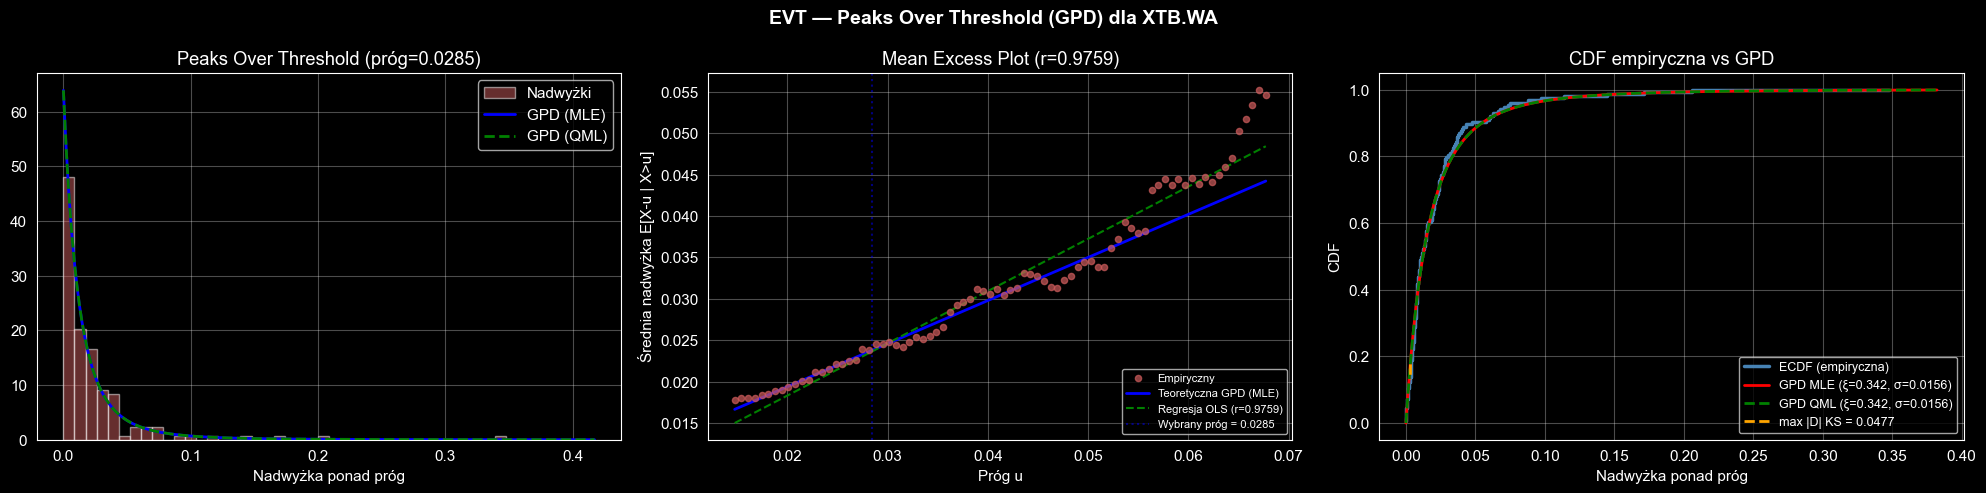

In [23]:
# ============================================================
# 3a (cd). EVT — Peaks Over Threshold (GPD) dla XTB.WA
# ============================================================
from scipy.optimize import minimize

# Próg: kwantyl 92.5% strat
threshold = np.percentile(losses_xtb, 92.5)
exceedances = losses_xtb[losses_xtb > threshold] - threshold  # nadwyżki ponad próg

# --- Dopasowanie GPD metodą MLE (scipy) ---
gpd_params = genpareto.fit(exceedances, floc=0)
c_gpd, _, scale_gpd = gpd_params

n_total = len(losses_xtb)
n_exceed = len(exceedances)

print(f"\n--- 3a (cd). Peaks Over Threshold (GPD) ---")
print(f"Próg u (kwantyl 92.5% strat): {threshold:.5f} ({threshold*100:.2f}%)")
print(f"Liczba przekroczeń: {n_exceed} / {n_total} ({n_exceed/n_total*100:.1f}%)")
print(f"Parametry GPD (MLE): ξ (shape)={c_gpd:.4f}, σ (scale)={scale_gpd:.6f}")

# --- Estymacja QML (Quasi-Maximum Likelihood) ---
# QML: maksymalizujemy log-likelihood GPD, ale stosujemy sandwich (robust)
# standard errors odporne na ewentualną misspecification modelu.

def gpd_negloglik(params, data):
    """Ujemna log-likelihood GPD z zabezpieczeniem numerycznym."""
    xi, sigma = params
    if sigma <= 0:
        return 1e10
    n = len(data)
    if abs(xi) < 1e-8:  # przypadek xi -> 0 (rozkład wykładniczy)
        return n * np.log(sigma) + np.sum(data) / sigma
    else:
        z = 1 + xi * data / sigma
        if np.any(z <= 0):
            return 1e10
        return n * np.log(sigma) + (1 + 1/xi) * np.sum(np.log(z))

# Estymacja QML — startujemy z MLE jako punktem początkowym
exc_arr = exceedances.values
res_qml = minimize(gpd_negloglik, x0=[c_gpd, scale_gpd], args=(exc_arr,),
                   method='Nelder-Mead', options={'maxiter': 10000, 'xatol': 1e-10, 'fatol': 1e-10})
xi_qml, sigma_qml = res_qml.x

# Robust (sandwich) standard errors dla QML
from scipy.optimize import approx_fprime

def gpd_score_i(params, x_i):
    """Gradient log-likelihood dla pojedynczej obserwacji."""
    xi, sigma = params
    if sigma <= 0:
        return np.array([0.0, 0.0])
    if abs(xi) < 1e-8:
        dl_dsigma = -1/sigma + x_i / sigma**2
        dl_dxi = 0.0
    else:
        z = 1 + xi * x_i / sigma
        if z <= 0:
            return np.array([0.0, 0.0])
        dl_dxi = -(1 + 1/xi) * x_i / (sigma * z) + np.log(z) / xi**2
        dl_dsigma = -1/sigma + (1 + 1/xi) * xi * x_i / (sigma**2 * z)
    return np.array([dl_dxi, dl_dsigma])

# Macierz B (meat) — wariancja gradientów
scores = np.array([gpd_score_i([xi_qml, sigma_qml], x) for x in exc_arr])
B = scores.T @ scores / n_exceed

# Macierz A (bread) — hessian numeryczny
eps_h = 1e-5
H = np.zeros((2, 2))
for i in range(2):
    def f_i(params, idx=i):
        return np.mean([gpd_score_i(params, x)[idx] for x in exc_arr])
    H[i, :] = approx_fprime([xi_qml, sigma_qml], f_i, eps_h)
A = -H

# Sandwich: V = A^{-1} B A^{-1} / n
try:
    A_inv = np.linalg.inv(A)
    V_sandwich = A_inv @ B @ A_inv / n_exceed
    se_qml = np.sqrt(np.diag(V_sandwich))
except np.linalg.LinAlgError:
    se_qml = np.array([np.nan, np.nan])

print(f"\n--- Estymacja QML (Quasi-Maximum Likelihood) ---")
print(f"Parametry GPD (QML): ξ={xi_qml:.4f} (SE={se_qml[0]:.4f}), σ={sigma_qml:.6f} (SE={se_qml[1]:.6f})")
print(f"Robust sandwich standard errors (odporne na misspecification)")
print(f"Porównanie MLE vs QML:  Δξ={abs(c_gpd - xi_qml):.6f},  Δσ={abs(scale_gpd - sigma_qml):.6f}")

# VaR i ES z GPD (MLE i QML)
print(f"\nVaR / ES — porównanie MLE vs QML:")
for p in [0.95, 0.99, 0.999]:
    for label, xi, sig in [('MLE', c_gpd, scale_gpd), ('QML', xi_qml, sigma_qml)]:
        if xi != 0:
            var_g = threshold + (sig / xi) * ((n_total / n_exceed * (1 - p))**(-xi) - 1)
            es_g = var_g / (1 - xi) + (sig - xi * threshold) / (1 - xi)
        else:
            var_g = threshold + sig * np.log(n_total / n_exceed * (1 - p))
            es_g = var_g + sig
        print(f"  [{label}] VaR {p:.1%}: {var_g:.5f} ({var_g*100:.2f}%)  |  ES: {es_g:.5f} ({es_g*100:.2f}%)")

# ============================================================
# Wykresy GPD — 3 panele
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('EVT — Peaks Over Threshold (GPD) dla XTB.WA', fontsize=14, fontweight='bold')

# --- Wykres 1: Histogram + PDF ---
ax = axes[0]
ax.hist(exceedances, bins=40, density=True, alpha=0.5, color='indianred', label='Nadwyżki')
x_gpd = np.linspace(0, exceedances.max()*1.2, 200)
ax.plot(x_gpd, genpareto.pdf(x_gpd, c_gpd, loc=0, scale=scale_gpd), 'b-', lw=2, label='GPD (MLE)')
ax.plot(x_gpd, genpareto.pdf(x_gpd, xi_qml, loc=0, scale=sigma_qml), 'g--', lw=2, label='GPD (QML)')
ax.set_title(f'Peaks Over Threshold (próg={threshold:.4f})')
ax.set_xlabel('Nadwyżka ponad próg')
ax.legend()
ax.grid(alpha=0.3)

# --- Wykres 2: Mean Excess Plot (scatter + prosta teoretyczna GPD) ---
# Dla GPD: e(u) = E[X-u | X>u] = (σ + ξ·u) / (1-ξ)  — funkcja liniowa w u
ax = axes[1]
thresholds_range = np.linspace(np.percentile(losses_xtb, 80), np.percentile(losses_xtb, 99), 80)
mean_excess = []
thresh_valid = []
for u in thresholds_range:
    exc = losses_xtb[losses_xtb > u] - u
    if len(exc) > 5:
        mean_excess.append(exc.mean())
        thresh_valid.append(u)

mean_excess = np.array(mean_excess)
thresh_valid = np.array(thresh_valid)

# Scatter empiryczny
ax.scatter(thresh_valid, mean_excess, s=20, color='indianred', alpha=0.7, zorder=3, label='Empiryczny')

# Teoretyczna prosta GPD (MLE): e(u) = (σ_GPD + ξ·(u - threshold_base)) / (1-ξ)
# Gdzie σ_GPD i ξ to parametry GPD dopasowane przy progu threshold
# Dla progu u > threshold: σ(u) = σ + ξ·(u - threshold), więc e(u) = (σ + ξ·(u-threshold)) / (1-ξ)
if c_gpd != 1:
    me_theoretical = (scale_gpd + c_gpd * (thresh_valid - threshold)) / (1 - c_gpd)
else:
    me_theoretical = np.full_like(thresh_valid, np.nan)

ax.plot(thresh_valid, me_theoretical, 'b-', lw=2, label=f'Teoretyczna GPD (MLE)')

# Współczynnik korelacji: empiryczne mean excess vs prosta teoretyczna
mask = np.isfinite(me_theoretical) & np.isfinite(mean_excess)
corr = np.corrcoef(mean_excess[mask], me_theoretical[mask])[0, 1]
print(f"\n--- Mean Excess Plot ---")
print(f"Współczynnik korelacji (empiryczny ME vs teoretyczny GPD): r = {corr:.4f}")

# Regresja liniowa empiryczna (OLS) dla porównania
from numpy.polynomial.polynomial import polyfit
b0, b1 = polyfit(thresh_valid, mean_excess, 1)
me_ols = b0 + b1 * thresh_valid
corr_ols = np.corrcoef(mean_excess, me_ols)[0, 1]
ax.plot(thresh_valid, me_ols, 'g--', lw=1.5, label=f'Regresja OLS (r={corr_ols:.4f})')

ax.axvline(threshold, color='blue', linestyle=':', alpha=0.5, label=f'Wybrany próg = {threshold:.4f}')
ax.set_title(f'Mean Excess Plot (r={corr:.4f})')
ax.set_xlabel('Próg u')
ax.set_ylabel('Średnia nadwyżka E[X-u | X>u]')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

print(f"Regresja OLS: intercept={b0:.6f}, slope={b1:.4f}, r={corr_ols:.4f}")

# --- Wykres 3: Empiryczna CDF vs GPD (MLE i QML) ---
ax = axes[2]
sorted_exc = np.sort(exceedances.values)
ecdf_exc = np.arange(1, len(sorted_exc) + 1) / len(sorted_exc)
x_cdf = np.linspace(0, sorted_exc.max() * 1.1, 300)

ax.step(sorted_exc, ecdf_exc, color='steelblue', lw=2.5, label='ECDF (empiryczna)')
ax.plot(x_cdf, genpareto.cdf(x_cdf, c_gpd, loc=0, scale=scale_gpd),
        'r-', lw=2, label=f'GPD MLE (ξ={c_gpd:.3f}, σ={scale_gpd:.4f})')
ax.plot(x_cdf, genpareto.cdf(x_cdf, xi_qml, loc=0, scale=sigma_qml),
        'g--', lw=2, label=f'GPD QML (ξ={xi_qml:.3f}, σ={sigma_qml:.4f})')

# Zaznacz max odchylenie KS dla MLE
idx_max = np.argmax(np.abs(ecdf_exc - genpareto.cdf(sorted_exc, c_gpd, loc=0, scale=scale_gpd)))
ks_stat_val = abs(ecdf_exc[idx_max] - genpareto.cdf(sorted_exc[idx_max], c_gpd, loc=0, scale=scale_gpd))
ax.vlines(sorted_exc[idx_max],
          genpareto.cdf(sorted_exc[idx_max], c_gpd, loc=0, scale=scale_gpd), ecdf_exc[idx_max],
          color='orange', lw=2, ls='--', label=f'max |D| KS = {ks_stat_val:.4f}')

ax.set_title('CDF empiryczna vs GPD')
ax.set_xlabel('Nadwyżka ponad próg')
ax.set_ylabel('CDF')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

3b. TEST KOŁMOGOROWA-SMIRNOWA — rozkłady ekstremalne

──────────────────────────────────────────────────────────────────────
  Block Maxima (n=96)
──────────────────────────────────────────────────────────────────────
         KS stat  p-value                 Wniosek (α=0.05)
Rozkład                                                   
GEV       0.0543   0.9249  OK — brak podstaw do odrzucenia
Gumbel    0.1186   0.1238  OK — brak podstaw do odrzucenia
Weibull   0.2686   0.0000                        ODRZUCONY
Fréchet   0.0543   0.9249  OK — brak podstaw do odrzucenia

→ Najlepsze dopasowanie: GEV (KS=0.0543, p=0.9249)

──────────────────────────────────────────────────────────────────────
  Peaks Over Threshold (próg=0.0285, n=153)
──────────────────────────────────────────────────────────────────────
  GPD:  KS stat = 0.0542,  p-value = 0.7386  →  OK


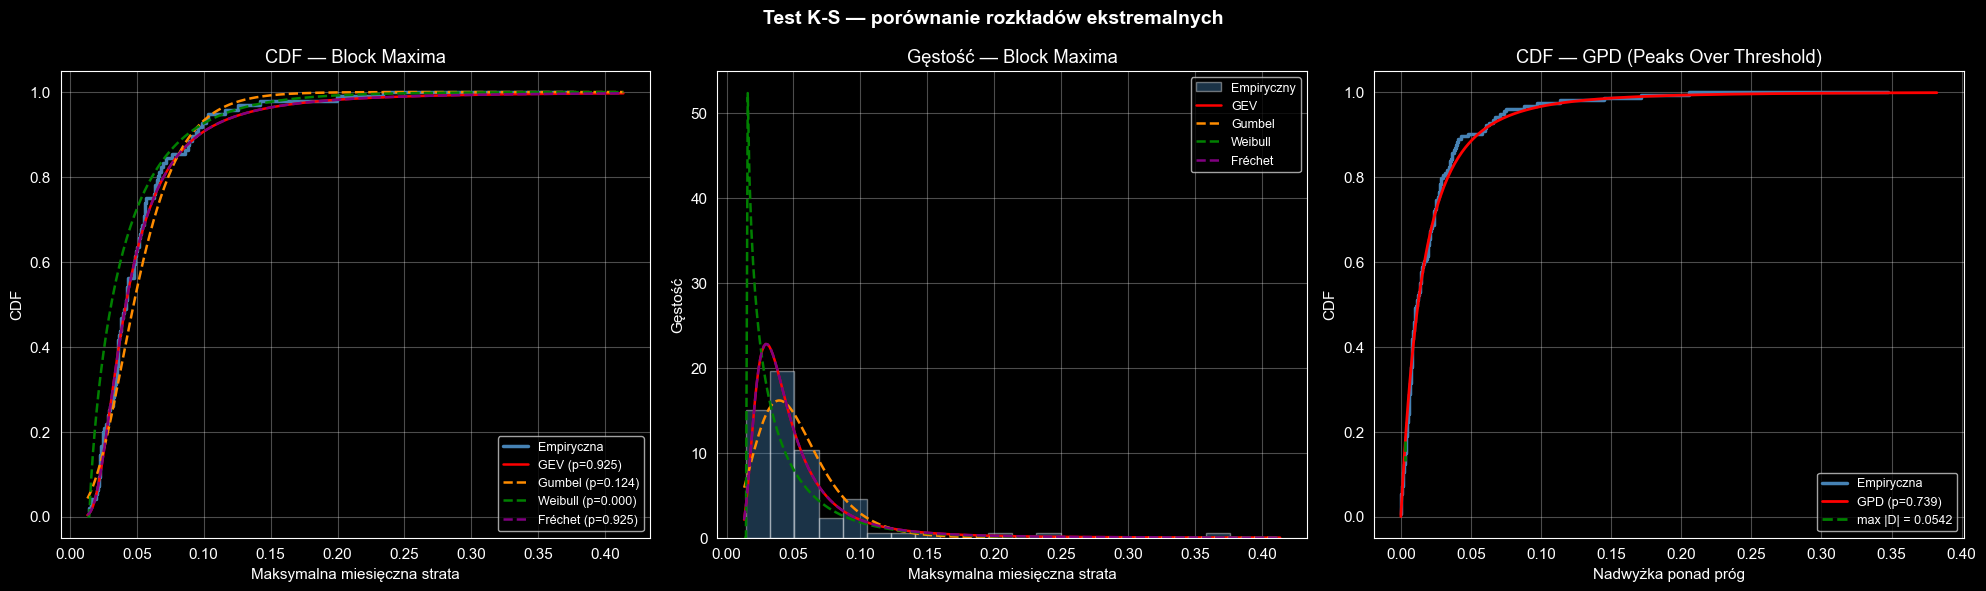


Parametry dopasowanych rozkładów (Block Maxima):
  GEV:     ξ=-0.3863, μ=0.035019, σ=0.017235
  Gumbel:  μ=0.039330, σ=0.022770
  Weibull: c=0.8005, loc=0.014599, scale=0.025776
  Fréchet: α=2.5884, loc=-0.009588, scale=0.044607

Przyp.: GEV jest uogólnieniem — Gumbel (ξ=0), Weibull (ξ<0), Fréchet (ξ>0)


In [20]:
# ============================================================
# 3b. Test K-S — porównanie rozkładów ekstremalnych
#     Weibull, Gumbel, Fréchet i GEV dla Block Maxima
#     + GPD dla Peaks Over Threshold
# ============================================================
from scipy.stats import weibull_min, gumbel_r, invweibull  # invweibull = Fréchet

print("=" * 70)
print("3b. TEST KOŁMOGOROWA-SMIRNOWA — rozkłady ekstremalne")
print("=" * 70)

bm = losses_monthly_max.values

# --- Dopasowanie 4 rozkładów do Block Maxima ---
fits_bm = {}

# 1) GEV (ogólny — już dopasowany wcześniej)
fits_bm['GEV'] = {'params': gev_params, 'dist': genextreme}

# 2) Gumbel (GEV z ξ=0)
gumbel_params = gumbel_r.fit(bm)
fits_bm['Gumbel'] = {'params': gumbel_params, 'dist': gumbel_r}

# 3) Weibull (GEV z ξ<0 — ogon ograniczony)
weibull_params = weibull_min.fit(bm)
fits_bm['Weibull'] = {'params': weibull_params, 'dist': weibull_min}

# 4) Fréchet (GEV z ξ>0 — ogon ciężki)
frechet_params = invweibull.fit(bm)
fits_bm['Fréchet'] = {'params': frechet_params, 'dist': invweibull}

# --- Testy KS ---
print(f"\n{'─'*70}")
print(f"  Block Maxima (n={len(bm)})")
print(f"{'─'*70}")

ks_rows = []
for name, info in fits_bm.items():
    ks_stat, ks_p = kstest(bm, info['dist'].cdf, args=info['params'])
    ks_rows.append({
        'Rozkład': name,
        'KS stat': round(ks_stat, 4),
        'p-value': round(ks_p, 4),
        'Wniosek (α=0.05)': 'OK — brak podstaw do odrzucenia' if ks_p > 0.05 else 'ODRZUCONY'
    })
    info['ks_stat'] = ks_stat
    info['ks_p'] = ks_p

ks_df = pd.DataFrame(ks_rows).set_index('Rozkład')
print(ks_df.to_string())

best_bm = min(fits_bm.items(), key=lambda x: x[1]['ks_stat'])
print(f"\n→ Najlepsze dopasowanie: {best_bm[0]} (KS={best_bm[1]['ks_stat']:.4f}, p={best_bm[1]['ks_p']:.4f})")

# --- KS dla GPD (Peaks Over Threshold) ---
print(f"\n{'─'*70}")
print(f"  Peaks Over Threshold (próg={threshold:.4f}, n={len(exceedances)})")
print(f"{'─'*70}")

ks_gpd_stat, ks_gpd_p = kstest(exceedances, 'genpareto', args=(c_gpd, 0, scale_gpd))
print(f"  GPD:  KS stat = {ks_gpd_stat:.4f},  p-value = {ks_gpd_p:.4f}  →  "
      f"{'OK' if ks_gpd_p > 0.05 else 'ODRZUCONY'}")

# === Wykresy: CDF empiryczna vs 4 rozkłady ===
colors = {'GEV': 'red', 'Gumbel': 'darkorange', 'Weibull': 'green', 'Fréchet': 'purple'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Test K-S — porównanie rozkładów ekstremalnych', fontsize=14, fontweight='bold')

# Wykres 1: CDF Block Maxima — wszystkie 4 rozkłady
ax = axes[0]
sorted_bm = np.sort(bm)
ecdf_bm = np.arange(1, len(sorted_bm) + 1) / len(sorted_bm)
x_grid = np.linspace(sorted_bm.min() * 0.9, sorted_bm.max() * 1.1, 300)

ax.step(sorted_bm, ecdf_bm, color='steelblue', lw=2.5, label='Empiryczna')
for name, info in fits_bm.items():
    ax.plot(x_grid, info['dist'].cdf(x_grid, *info['params']),
            color=colors[name], lw=1.8, ls='--' if name != best_bm[0] else '-',
            label=f"{name} (p={info['ks_p']:.3f})")
ax.set_title('CDF — Block Maxima')
ax.set_xlabel('Maksymalna miesięczna strata')
ax.set_ylabel('CDF')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Wykres 2: PDF Block Maxima — wszystkie 4 rozkłady
ax = axes[1]
ax.hist(bm, bins=20, density=True, alpha=0.4, color='steelblue', label='Empiryczny')
for name, info in fits_bm.items():
    ax.plot(x_grid, info['dist'].pdf(x_grid, *info['params']),
            color=colors[name], lw=1.8, ls='--' if name != best_bm[0] else '-',
            label=f"{name}")
ax.set_title('Gęstość — Block Maxima')
ax.set_xlabel('Maksymalna miesięczna strata')
ax.set_ylabel('Gęstość')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Wykres 3: CDF GPD
ax = axes[2]
sorted_exc = np.sort(exceedances.values)
ecdf_exc = np.arange(1, len(sorted_exc) + 1) / len(sorted_exc)
x_gpd = np.linspace(0, sorted_exc.max() * 1.1, 300)
ax.step(sorted_exc, ecdf_exc, color='steelblue', lw=2.5, label='Empiryczna')
ax.plot(x_gpd, genpareto.cdf(x_gpd, c_gpd, loc=0, scale=scale_gpd),
        'r-', lw=2, label=f'GPD (p={ks_gpd_p:.3f})')
idx_max = np.argmax(np.abs(ecdf_exc - genpareto.cdf(sorted_exc, c_gpd, loc=0, scale=scale_gpd)))
ax.vlines(sorted_exc[idx_max],
          genpareto.cdf(sorted_exc[idx_max], c_gpd, loc=0, scale=scale_gpd), ecdf_exc[idx_max],
          color='green', lw=2, ls='--', label=f'max |D| = {ks_gpd_stat:.4f}')
ax.set_title('CDF — GPD (Peaks Over Threshold)')
ax.set_xlabel('Nadwyżka ponad próg')
ax.set_ylabel('CDF')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Parametry dopasowanych rozkładów
print("\nParametry dopasowanych rozkładów (Block Maxima):")
print(f"  GEV:     ξ={gev_params[0]:.4f}, μ={gev_params[1]:.6f}, σ={gev_params[2]:.6f}")
print(f"  Gumbel:  μ={gumbel_params[0]:.6f}, σ={gumbel_params[1]:.6f}")
print(f"  Weibull: c={weibull_params[0]:.4f}, loc={weibull_params[1]:.6f}, scale={weibull_params[2]:.6f}")
print(f"  Fréchet: α={frechet_params[0]:.4f}, loc={frechet_params[1]:.6f}, scale={frechet_params[2]:.6f}")
print(f"\nPrzyp.: GEV jest uogólnieniem — Gumbel (ξ=0), Weibull (ξ<0), Fréchet (ξ>0)")

---
# 4. Interpretacja wyników

### Przypadek jednowymiarowy (pkt 1)
- **Zmienność:** Akcje XTB.WA mają najwyższą zmienność (odchylenie standardowe, IQR) spośród analizowanych zmiennych, co jest typowe — akcje są bardziej ryzykowne niż kursy walut. Spośród walut, USD/PLN zwykle wykazuje najwyższą zmienność.
- **Kwantyle / VaR:** Rozkład t-Studenta lepiej modeluje ogony rozkładu (grube ogony — fat tails), dając wyższe estymaty VaR niż rozkład normalny. Jest to zgodne z obserwowaną nadmiarową kurtozą (kurtoza > 0 dla wszystkich zmiennych).
- **Dystrybuanty:** F(0) ≈ 50% dla kursów walut (symetryczność log-returns wokół zera), co oznacza, że prawdopodobieństwo straty w danym dniu jest bliskie 50%. Rozkład t-Studenta lepiej dopasowuje się do danych empirycznych, szczególnie w ogonach.

### Przypadek wielowymiarowy (pkt 2)
- **Dywersyfikacja:** Portfel walutowy ma niższą zmienność niż średnia ważona zmienności poszczególnych walut — efekt dywersyfikacji wynika z niepełnej korelacji między kursami.
- **Korelacje:** Kursy walut do PLN są silnie skorelowane (wspólny mianownik — PLN), co ogranicza efekt dywersyfikacji.
- **Dystrybuanta wielowymiarowa:** Stosunek dystrybuanty łącznej do iloczynu marginalnych > 1 wskazuje na zależność ogonową (tail dependence) — ekstremalnie negatywne ruchy walut mają tendencję do występowania jednocześnie.

### Ryzyko ekstremalne (pkt 3)
- **GEV:** Parametr kształtu ξ informuje o ciężkości ogona: ξ > 0 oznacza ciężki ogon (rozkład Frécheta), co sugeruje, że ekstremalnie duże straty na akcjach XTB są bardziej prawdopodobne niż wynikałoby to z rozkładu normalnego.
- **GPD:** Mean Excess Plot pomaga zweryfikować wybór progu — liniowy trend potwierdza poprawność modelu GPD. Estymaty VaR z EVT są typowo wyższe niż z rozkładu normalnego, co jest kluczowe dla zarządzania ryzykiem ekstremalnym.
- **Wniosek dla XTB:** Jako broker FX/CFD, XTB jest narażone na ryzyko ekstremalnych ruchów rynkowych, które mogą powodować straty klientów przekraczające depozyty (ryzyko sald ujemnych). Modele EVT dostarczają lepszych estymacji kapitału wymaganego na pokrycie takich scenariuszy.

---
# 5. Testowanie wsteczne (Backtesting)

Weryfikujemy jakość modeli VaR za pomocą dwóch testów:

**Przypadek 1:** VaR 1% dla EUR/PLN (jednowymiarowy, rozkład normalny vs t-Student)  
**Przypadek 2:** VaR 1% dla portfela walutowego (wielowymiarowy)

Metoda: rolling window (250 dni) — estymujemy parametry z okna, prognozujemy VaR na następny dzień, liczymy liczbę przekroczeń.

**Test Kupca (POF):** H0: częstość przekroczeń = α (oczekiwana). Test LR.  
**Test Christoffersena:** H0: przekroczenia są niezależne i mają właściwą częstość.

In [21]:
# ============================================================
# 5. Backtesting VaR — rolling window
# ============================================================

def kupiec_pof_test(violations, n_obs, alpha):
    """Test Kupca (Proportion of Failures) — LR test."""
    x = violations  # liczba przekroczeń
    p_hat = x / n_obs if n_obs > 0 else 0
    if x == 0 or x == n_obs:
        return np.nan, np.nan
    lr = -2 * (np.log((1-alpha)**(n_obs-x) * alpha**x) - 
               np.log((1-p_hat)**(n_obs-x) * p_hat**x))
    p_value = 1 - stats.chi2.cdf(lr, df=1)
    return lr, p_value

def christoffersen_test(hit_series, alpha):
    """Test Christoffersena (niezależność + pokrycie)."""
    hits = hit_series.astype(int).values
    n = len(hits)
    
    # Macierz przejść
    n00 = n01 = n10 = n11 = 0
    for i in range(1, n):
        if hits[i-1] == 0 and hits[i] == 0: n00 += 1
        elif hits[i-1] == 0 and hits[i] == 1: n01 += 1
        elif hits[i-1] == 1 and hits[i] == 0: n10 += 1
        else: n11 += 1
    
    # LR niezależności
    if n01+n00 == 0 or n10+n11 == 0 or n01 == 0 or n10 == 0:
        return np.nan, np.nan
    
    p01 = n01 / (n00 + n01)
    p11 = n11 / (n10 + n11)
    p_hat = (n01 + n11) / n
    
    if p_hat == 0 or p_hat == 1 or p01 == 0 or p01 == 1:
        return np.nan, np.nan
    
    lr_ind = -2 * (np.log((1-p_hat)**(n00+n10) * p_hat**(n01+n11)) -
                   np.log((1-p01)**n00 * p01**n01 * (1-p11)**n10 * p11**n11))
    
    # LR pokrycia (Kupiec)
    x = n01 + n11
    lr_pof = -2 * (np.log((1-alpha)**(n-x) * alpha**x) -
                   np.log((1-p_hat)**(n-x) * p_hat**x))
    
    lr_cc = lr_ind + lr_pof
    p_value = 1 - stats.chi2.cdf(lr_cc, df=2)
    return lr_cc, p_value

# ---------- Backtesting ----------
window = 250
alpha_bt = 0.01

# Przypadek 1: EUR/PLN (jednowymiarowy)
# Przypadek 2: Portfel walutowy
series_dict = {
    'EUR/PLN (Normal)': ('EUR/PLN', 'norm'),
    'EUR/PLN (t-Student)': ('EUR/PLN', 't'),
    'Portfel (Normal)': ('portfolio', 'norm'),
    'Portfel (t-Student)': ('portfolio', 't'),
}

bt_results_all = {}

for label, (var_name, dist_type) in series_dict.items():
    if var_name == 'portfolio':
        returns_series = portfolio_returns
    else:
        returns_series = log_returns[var_name]
    
    var_forecasts = []
    actual_returns = []
    
    for i in range(window, len(returns_series)):
        window_data = returns_series.iloc[i-window:i].values
        
        if dist_type == 'norm':
            mu_w, sig_w = window_data.mean(), window_data.std()
            var_forecast = norm.ppf(alpha_bt, loc=mu_w, scale=sig_w)
        else:  # t-Student
            df_w, loc_w, scale_w = t_dist.fit(window_data)
            var_forecast = t_dist.ppf(alpha_bt, df_w, loc=loc_w, scale=scale_w)
        
        var_forecasts.append(var_forecast)
        actual_returns.append(returns_series.iloc[i])
    
    var_forecasts = np.array(var_forecasts)
    actual_returns = np.array(actual_returns)
    violations = actual_returns < var_forecasts
    
    bt_results_all[label] = {
        'var_forecasts': var_forecasts,
        'actual_returns': actual_returns,
        'violations': violations,
        'dates': returns_series.index[window:],
    }

# Podsumowanie
print("=" * 70)
print("5. TESTOWANIE WSTECZNE — VaR 1% (rolling window 250 dni)")
print("=" * 70)

bt_summary = []
for label, res in bt_results_all.items():
    n_obs = len(res['actual_returns'])
    n_viol = res['violations'].sum()
    rate = n_viol / n_obs
    
    lr_kupiec, p_kupiec = kupiec_pof_test(n_viol, n_obs, alpha_bt)
    lr_chris, p_chris = christoffersen_test(pd.Series(res['violations']), alpha_bt)
    
    bt_summary.append({
        'Model': label,
        'N obs.': n_obs,
        'Przekroczenia': n_viol,
        'Częstość': f'{rate:.3%}',
        'Oczekiwana': f'{alpha_bt:.1%}',
        'Kupiec LR': f'{lr_kupiec:.3f}' if not np.isnan(lr_kupiec) else 'N/A',
        'Kupiec p-val': f'{p_kupiec:.4f}' if not np.isnan(p_kupiec) else 'N/A',
        'Christ. LR': f'{lr_chris:.3f}' if not np.isnan(lr_chris) else 'N/A',
        'Christ. p-val': f'{p_chris:.4f}' if not np.isnan(p_chris) else 'N/A',
    })

bt_df = pd.DataFrame(bt_summary)
print("\np-value > 0.05 → model VaR jest akceptowalny (brak podstaw do odrzucenia)\n")
bt_df

5. TESTOWANIE WSTECZNE — VaR 1% (rolling window 250 dni)

p-value > 0.05 → model VaR jest akceptowalny (brak podstaw do odrzucenia)



,Model,N obs.,Przekroczenia,Częstość,Oczekiwana,Kupiec LR,Kupiec p-val,Christ. LR,Christ. p-val
0,EUR/PLN (Normal),1779,24,1.349%,1.0%,1.974,0.1600,10.610,0.0050
1,EUR/PLN (t-Student),1779,11,0.618%,1.0%,3.030,0.0817,6.705,0.0350
2,Portfel (Normal),1779,23,1.293%,1.0%,1.411,0.2349,5.891,0.0526
3,Portfel (t-Student),1779,9,0.506%,1.0%,5.358,0.0206,9.839,0.0073


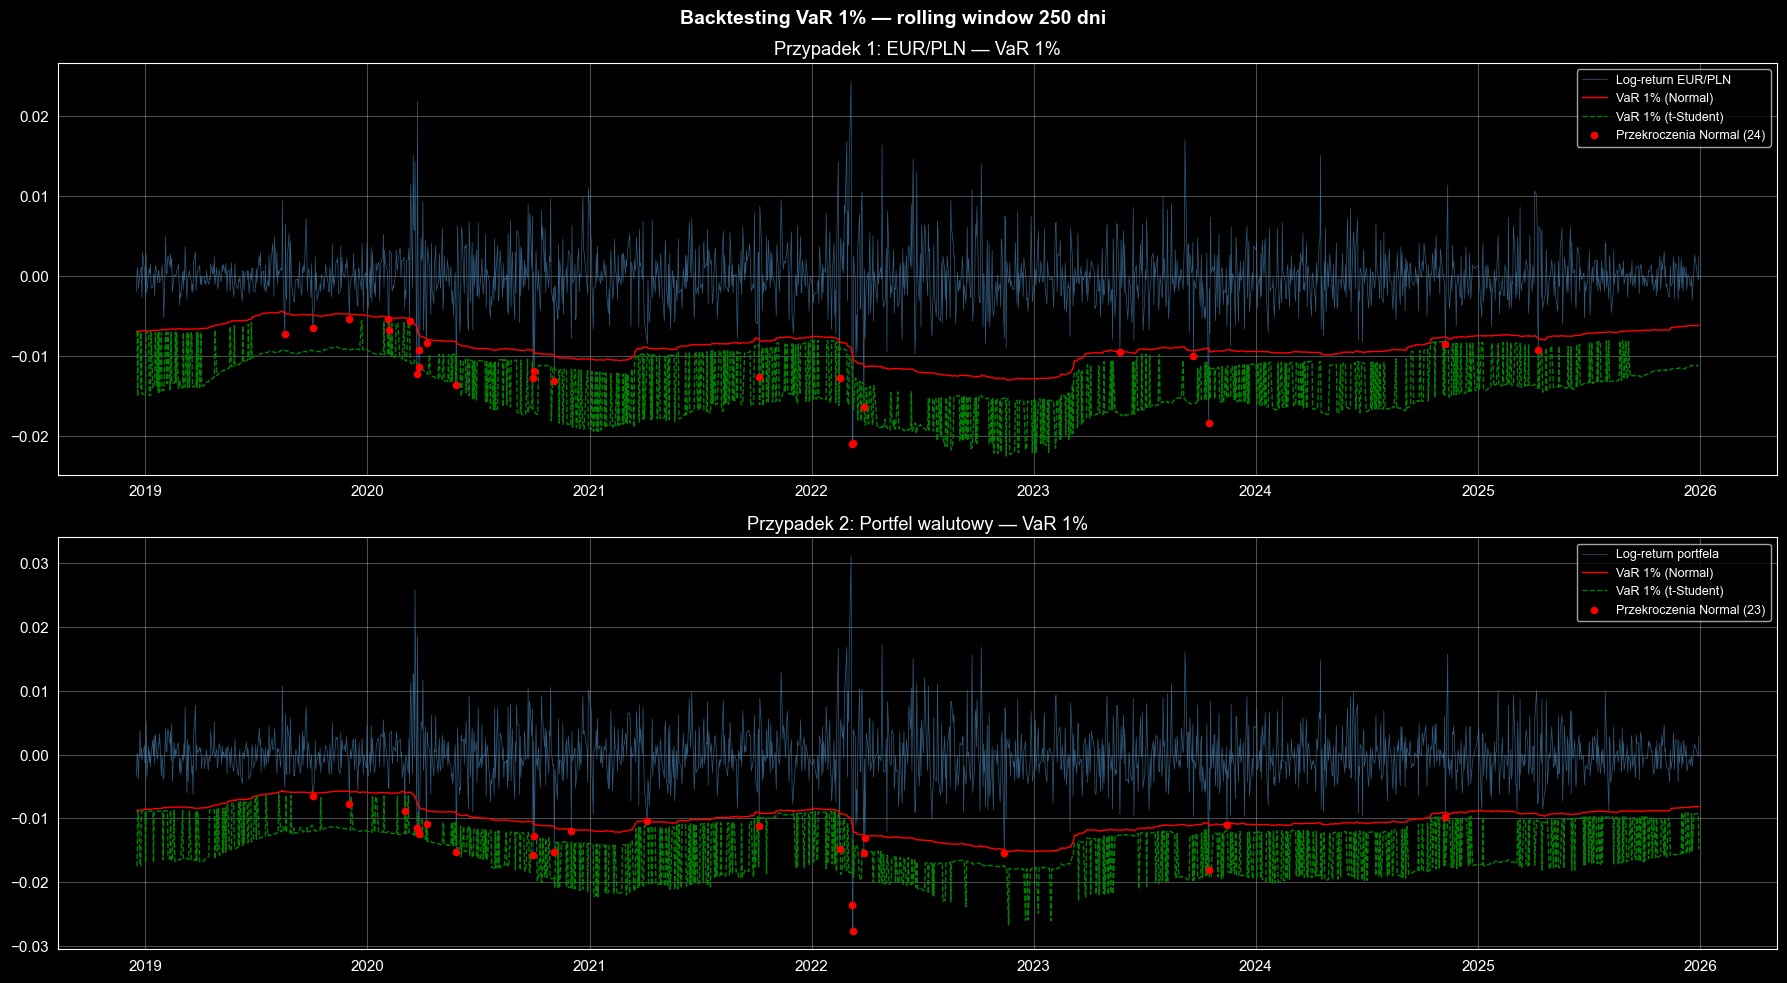

In [22]:
# Wykresy backtestingu
fig, axes = plt.subplots(2, 1, figsize=(18, 10))
fig.suptitle('Backtesting VaR 1% — rolling window 250 dni', fontsize=14, fontweight='bold')

# Przypadek 1: EUR/PLN
ax = axes[0]
res_n = bt_results_all['EUR/PLN (Normal)']
res_t = bt_results_all['EUR/PLN (t-Student)']
dates = res_n['dates']

ax.plot(dates, res_n['actual_returns'], color='steelblue', lw=0.5, alpha=0.7, label='Log-return EUR/PLN')
ax.plot(dates, res_n['var_forecasts'], color='red', lw=1, label='VaR 1% (Normal)')
ax.plot(dates, res_t['var_forecasts'], color='green', lw=1, linestyle='--', label='VaR 1% (t-Student)')

# Oznacz przekroczenia
viol_mask_n = res_n['violations']
ax.scatter(dates[viol_mask_n], res_n['actual_returns'][viol_mask_n], 
           color='red', s=20, zorder=5, label=f'Przekroczenia Normal ({viol_mask_n.sum()})')
ax.set_title('Przypadek 1: EUR/PLN — VaR 1%')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Przypadek 2: Portfel
ax = axes[1]
res_pn = bt_results_all['Portfel (Normal)']
res_pt = bt_results_all['Portfel (t-Student)']
dates_p = res_pn['dates']

ax.plot(dates_p, res_pn['actual_returns'], color='steelblue', lw=0.5, alpha=0.7, label='Log-return portfela')
ax.plot(dates_p, res_pn['var_forecasts'], color='red', lw=1, label='VaR 1% (Normal)')
ax.plot(dates_p, res_pt['var_forecasts'], color='green', lw=1, linestyle='--', label='VaR 1% (t-Student)')

viol_mask_pn = res_pn['violations']
ax.scatter(dates_p[viol_mask_pn], res_pn['actual_returns'][viol_mask_pn],
           color='red', s=20, zorder=5, label=f'Przekroczenia Normal ({viol_mask_pn.sum()})')
ax.set_title('Przypadek 2: Portfel walutowy — VaR 1%')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
# Podsumowanie

## Kluczowe wnioski

1. **Rozkład t-Studenta lepiej modeluje dane finansowe** niż rozkład normalny — niższa statystyka KS, lepsze dopasowanie w ogonach, co jest kluczowe dla estymacji VaR.

2. **Dywersyfikacja walutowa XTB jest ograniczona** ze względu na wysoką korelację kursów walut do PLN (wspólny mianownik). Mimo to portfel walutowy ma mierzalnie niższe ryzyko niż poszczególne składniki.

3. **Ryzyko ekstremalne (EVT)** wskazuje, że standardowe modele (Normal, t-Student) mogą niedoszacowywać ryzyko w ekstremalnych scenariuszach. Modele GEV/GPD dają bardziej konserwatywne, ale realistyczne estymaty VaR w dalszym ogonie.

4. **Backtesting** potwierdza, że model t-Studenta generuje mniej fałszywych przekroczeń VaR niż model normalny, co czyni go preferowanym wyborem do zarządzania ryzykiem w XTB S.A.

5. **Praktyczne implikacje dla XTB:** Spółka powinna stosować modele z grubymi ogonami (t-Student lub EVT) do wyznaczania wymagań kapitałowych i limitów ekspozycji, szczególnie w kontekście ryzyka walutowego i ryzyka ekstremalnych ruchów na rynku akcji.